# 07 — Final Comparison & Supplementary Materials

**Pipeline stage 7 of 7.** Assemble the paper's headline comparison table,
run paired bootstrap significance tests on Brier score, and render
publication-quality supplementary tables (`.docx`) and figures (`.png`/`.pdf`).

**Inputs**
- All probability streams (notebook 06)
- Baseline metrics + bootstrap CIs (notebooks 03 and 05)
- EnKF metrics (notebook 04)
- Sensitivity results (notebook 05)

**Outputs**
- Final comparison table (CSV + plot)
- `.docx` supplementary tables (Part 20)
- `.png` / `.pdf` supplementary figures (Part 21)
- Paired-bootstrap significance results

> Source: Parts 20, 21, 27 of the original monolithic notebook.


## Setup

In [1]:
!pip install -q python-docx scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats

from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, f1_score, accuracy_score,
                             precision_score, recall_score)

from shared_config import *
print_config_summary()

--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
EnKF Propagator:               SeasonalAR1
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load all upstream artifacts

In [3]:
# --- Probability streams from notebook 06 ---
if not os.path.exists(ALT_MODEL_STREAMS_PATH):
    raise FileNotFoundError("Alternative-model streams missing; run notebook 06 first.")

with np.load(ALT_MODEL_STREAMS_PATH) as data:
    streams = {k: data[k] for k in data.files}

y_eval_full = streams.pop("y_test")
n_eval = len(y_eval_full)

def _pick(key, label):
    arr = streams.get(key)
    if arr is None:
        print(f"  [missing] {label:30s} ({key!r})")
        return None
    if len(arr) != n_eval:
        print(f"  [shape mismatch] {label}: got {len(arr)}, expected {n_eval}; tail alignment will be used.")
    return arr

print("Loading per-model probability streams:")
lstm_p_test = _pick("lstm", "Standalone LSTM")
var_prob_eval = _pick("var", "VAR baseline")
p_regime_blend = _pick("regime_switching", "Regime-switching dual LSTM")
pinn_bloom_pred = _pick("pinn", "PINN-LSTM")
p_lstm_gp = _pick("lstm_gp", "LSTM + GP residual")
blended = _pick("hybrid_ensemble", "Hybrid ensemble")

if lstm_p_test is None and os.path.exists(LSTM_TEST_PROBS_PATH):
    lstm_p_test = np.load(LSTM_TEST_PROBS_PATH)
    print(f"  recovered standalone LSTM stream from {LSTM_TEST_PROBS_PATH}")

mc_preds = np.load(MC_PREDS_PATH) if os.path.exists(MC_PREDS_PATH) else None
y_trim_path = os.path.join(INTERMEDIATE_DIR, "y_test_trimmed.npy")
y_test_trimmed = np.load(y_trim_path) if os.path.exists(y_trim_path) else None


def _collapse_to_point_stream(arr):
    """Collapse an MC / ensemble tensor to a 1-D per-sample point estimate.

    Handles the updated notebook 04b 3-D tensor (n_samples, n_enkf, n_mc),
    an older 2-D (n_samples, n_mc) tensor, or an already-1-D stream. The mean
    is taken over every axis except the leading sample axis. Using .flatten()
    here would explode an (n, 50) tensor into n*50 values and break every
    length check downstream, so always reduce instead.
    """
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim <= 1:
        return arr.flatten()
    return arr.reshape(arr.shape[0], -1).mean(axis=1)


if mc_preds is not None:
    enkf_hybrid_prob = _collapse_to_point_stream(mc_preds)
    print(f"  [available] LSTM-EnKF preprocessor MC stream "
          f"{mc_preds.shape} -> point stream {enkf_hybrid_prob.shape}")
elif os.path.exists(LSTM_ENKF_TEST_PROBS_PATH):
    enkf_hybrid_prob = np.asarray(np.load(LSTM_ENKF_TEST_PROBS_PATH)).flatten()
    print(f"  [available] LSTM-EnKF deterministic stream {enkf_hybrid_prob.shape}")
else:
    _picked = _pick("lstm_enkf_preprocessor", "LSTM-EnKF preprocessor")
    enkf_hybrid_prob = None if _picked is None else np.asarray(_picked).flatten()

# Align the saved trimmed ground truth to the hybrid stream length. The on-disk
# y_test_trimmed.npy can be stale (written at a different seq_length than the
# current mc_preds), so trim it to the trailing n_samples instead of trusting
# its raw length. This prevents the 234-vs-232 / 234-vs-N*50 mismatches.
if enkf_hybrid_prob is not None and y_test_trimmed is not None:
    _yt = np.asarray(y_test_trimmed).flatten()
    _n = len(enkf_hybrid_prob)
    if len(_yt) != _n:
        print(f"  [align] y_test_trimmed {len(_yt)} -> {_n} (trailing slice) "
              f"to match hybrid stream")
        if len(_yt) > _n:
            y_test_trimmed = _yt[-_n:]
        else:
            # truth shorter than stream: fall back to y_eval_full's tail if usable
            _yf = np.asarray(y_eval_full).flatten()
            y_test_trimmed = _yf[-_n:] if len(_yf) >= _n else _yt
    else:
        y_test_trimmed = _yt

bs_path = os.path.join(INTERMEDIATE_DIR, "bootstrap_results.json")
bootstrap_ci = json.load(open(bs_path)) if os.path.exists(bs_path) else {}

sensitivity_results = {}
sensitivity_results_q = {}
sensitivity_results_n = {}
sensitivity_results_propagator = {}
if os.path.exists(SENSITIVITY_RESULTS_PATH):
    with open(SENSITIVITY_RESULTS_PATH) as f:
        _sens = json.load(f)
    if "q_scaling" in _sens:
        sensitivity_results_q = {float(k): v for k, v in _sens["q_scaling"].items()}
    if "ensemble_size" in _sens:
        sensitivity_results_n = {int(k): v for k, v in _sens["ensemble_size"].items()}
    if "propagator" in _sens:
        sensitivity_results_propagator = dict(_sens["propagator"])
    sensitivity_results = _sens

if not sensitivity_results_propagator and "PROPAGATOR_RESULTS_PATH" in dir() and os.path.exists(PROPAGATOR_RESULTS_PATH):
    with open(PROPAGATOR_RESULTS_PATH) as f:
        sensitivity_results_propagator = dict(json.load(f))

enkf_metrics = json.load(open(ENKF_METRICS_PATH)) if os.path.exists(ENKF_METRICS_PATH) else {}
baseline_metrics = json.load(open(BASELINE_METRICS_PATH)) if os.path.exists(BASELINE_METRICS_PATH) else {}
alt_tuning_summary = json.load(open(ALT_MODEL_TUNING_SUMMARY_PATH)) if os.path.exists(ALT_MODEL_TUNING_SUMMARY_PATH) else {}

BASELINE_RESULTS_PATH = os.path.join(INTERMEDIATE_DIR, "simple_baselines_results.json")
BASELINE_PREDS_PATH = os.path.join(INTERMEDIATE_DIR, "simple_baselines_preds.npz")
baseline_results = None
if os.path.exists(BASELINE_RESULTS_PATH):
    with open(BASELINE_RESULTS_PATH) as f:
        baseline_results = json.load(f)
    if os.path.exists(BASELINE_PREDS_PATH):
        with np.load(BASELINE_PREDS_PATH) as preds:
            pred_files = list(preds.files)
            for name in list(baseline_results.keys()):
                safe = name.replace(" ", "_").replace(".", "")
                if f"{safe}__y_pred" in preds.files:
                    baseline_results[name]["y_pred"] = preds[f"{safe}__y_pred"]
                if f"{safe}__y_prob" in preds.files:
                    baseline_results[name]["y_prob"] = preds[f"{safe}__y_prob"]
        print(f"baseline arrays: {sorted(set(k.split('__')[0] for k in pred_files))}")

print(f"\nn_eval={n_eval}, positive rate={y_eval_full.mean():.3f}")
print(f"bootstrap_ci keys: {list(bootstrap_ci.keys())[:6] or '(empty)'}")
print(f"sensitivity q/n/prop: {len(sensitivity_results_q)}/{len(sensitivity_results_n)}/{len(sensitivity_results_propagator)}")
print(f"alt tuning summary keys: {list(alt_tuning_summary.keys()) or '(empty)'}")


Loading per-model probability streams:
  [available] LSTM-EnKF preprocessor MC stream (216, 50, 50) -> point stream (216,)
baseline arrays: ['Climatology', 'Logistic_Reg', 'Persistence', 'Random_Forest']

n_eval=216, positive rate=0.324
bootstrap_ci keys: ['standalone_lstm', 'lstm_enkf_preprocessor']
sensitivity q/n/prop: 0/0/4
alt tuning summary keys: ['regime_specialists', 'pinn_lstm', 'arima', 'kalman', 'hedge_blend']


In [4]:
# --- Stats helpers (originally defined in notebook 05's Part 16) ---
from scipy import stats as _sp_stats
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, brier_score_loss)

N_BOOTSTRAP = 2000
CI_LEVEL    = 0.95
BOOT_SEED   = 42

def bootstrap_classification_metrics(y_true, y_pred, y_prob,
                                     n_bootstrap=N_BOOTSTRAP, ci_level=CI_LEVEL,
                                     seed=BOOT_SEED):
    """Bootstrap 95% CIs for accuracy, precision, recall, F1, Brier."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    metric_fns = {
        'Accuracy':  lambda yt, yp, yprob: accuracy_score(yt, yp),
        'Precision': lambda yt, yp, yprob: precision_score(yt, yp, zero_division=0),
        'Recall':    lambda yt, yp, yprob: recall_score(yt, yp, zero_division=0),
        'F1':        lambda yt, yp, yprob: f1_score(yt, yp, zero_division=0),
        'Brier':     lambda yt, yp, yprob: brier_score_loss(yt, yprob),
    }
    results = {}
    for name, fn in metric_fns.items():
        boot_vals = []
        for _ in range(n_bootstrap):
            idx = rng.choice(n, size=n, replace=True)
            yt_b, yp_b, yprob_b = y_true[idx], y_pred[idx], y_prob[idx]
            if name != 'Brier' and len(np.unique(yt_b)) < 2:
                continue
            if np.sum(yp_b) == 0 and name in ('Precision', 'F1'):
                continue
            try:
                boot_vals.append(fn(yt_b, yp_b, yprob_b))
            except Exception:
                continue
        try:
            point = fn(y_true, y_pred, y_prob)
        except Exception:
            point = float('nan')
        boot_arr = np.array(boot_vals)
        if boot_arr.size == 0:
            ci_lo = ci_hi = float('nan')
        else:
            alpha = 1 - ci_level
            ci_lo = float(np.percentile(boot_arr, 100 * alpha / 2))
            ci_hi = float(np.percentile(boot_arr, 100 * (1 - alpha / 2)))
        results[name] = {'point': float(point), 'ci_lo': ci_lo, 'ci_hi': ci_hi,
                         'n_valid': int(boot_arr.size)}
    return results

def clopper_pearson(k, n, alpha=0.05):
    """Exact binomial CI for proportion k/n."""
    if n == 0:
        return (0.0, 0.0)
    lo = _sp_stats.beta.ppf(alpha / 2, k, n - k + 1)        if k > 0 else 0.0
    hi = _sp_stats.beta.ppf(1 - alpha / 2, k + 1, n - k)    if k < n else 1.0
    return (float(lo), float(hi))

## Part 27: Final Comparison & Ablation

Side-by-side metrics on the test set. Also runs **DeLong's test** (AUC) and a paired bootstrap on Brier score to check whether differences are statistically significant.


In [5]:
# --- Part 27: Build comparison table ---
import pandas as pd

def _model_metrics(y_true, y_prob, threshold=0.5):
    if y_prob is None:
        return None
    y_prob = np.asarray(y_prob).flatten()
    y_true = np.asarray(y_true).flatten()
    if len(y_prob) != len(y_true):
        n = min(len(y_prob), len(y_true))
        y_prob = y_prob[-n:]
        y_true = y_true[-n:]
    return {
        "AUC": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "AUPRC": average_precision_score(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob),
        "F1@0.5": f1_score(y_true, (y_prob >= threshold).astype(int), zero_division=0),
    }

y_for_enkf = y_test_trimmed if y_test_trimmed is not None else y_eval_full

candidate_streams = [
    ("Standalone LSTM", lstm_p_test, y_eval_full),
    ("LSTM-EnKF preprocessor", enkf_hybrid_prob, y_for_enkf),
    ("VAR", var_prob_eval, y_eval_full),
    ("Regime-switching", p_regime_blend, y_eval_full),
    ("PINN-augmented LSTM", pinn_bloom_pred, y_eval_full),
    ("LSTM + GP", p_lstm_gp, y_eval_full),
    ("Hybrid ensemble", blended, y_eval_full),
]

all_results = {}
for name, prob, y_for_this in candidate_streams:
    m = _model_metrics(y_for_this, prob)
    if m is None:
        print(f"  Skipping '{name}' (no probability stream).")
        continue
    all_results[name] = m

results_df = pd.DataFrame(all_results).T
print("\n========== COMPARISON ==========")
print(results_df.round(4).to_string())

os.makedirs(OUTPUT_DIR, exist_ok=True)
csv_path = os.path.join(OUTPUT_DIR, "model_comparison.csv")
results_df.to_csv(csv_path)
print(f"\nSaved: {csv_path}")

print("\nBest per metric:")
for col in results_df.columns:
    winner = results_df[col].idxmin() if col == "Brier" else results_df[col].idxmax()
    print(f"  {col:8s}: {winner} ({results_df.loc[winner, col]:.4f})")



========== COMPARISON ==========
                           AUC   AUPRC   Brier  F1@0.5
Standalone LSTM         0.9477  0.9049  0.1736  0.6970
LSTM-EnKF preprocessor  0.9473  0.9067  0.1658  0.7071
VAR                     0.9645  0.9118  0.1080  0.6481
Regime-switching        0.9672  0.9256  0.0744  0.8758
PINN-augmented LSTM     0.9530  0.8666  0.0962  0.8176
LSTM + GP               0.9399  0.7945  0.0984  0.8025
Hybrid ensemble         0.9657  0.9156  0.0710  0.8630

Saved: output_refactored/model_comparison.csv

Best per metric:
  AUC     : Regime-switching (0.9672)
  AUPRC   : Regime-switching (0.9256)
  Brier   : Hybrid ensemble (0.0710)
  F1@0.5  : Regime-switching (0.8758)


In [6]:
# --- Paired bootstrap significance test on Brier score ---
def bootstrap_brier_diff(y, pA, pB, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y)
    diffs = []
    base = brier_score_loss(y, pA) - brier_score_loss(y, pB)
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        diffs.append(brier_score_loss(y[idx], pA[idx]) - brier_score_loss(y[idx], pB[idx]))
    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_val = 2 * min((diffs >= 0).mean(), (diffs <= 0).mean())
    return base, ci_low, ci_high, p_val

# Compare each new model vs LSTM baseline
probs_map = {
    'VAR': var_prob_eval,
    'Regime-switching': p_regime_blend,
    'PINN-augmented LSTM': pinn_bloom_pred,
    'LSTM + GP': p_lstm_gp,
    'Hybrid ensemble': blended,
}

print('Paired bootstrap — ΔBrier vs LSTM baseline (negative = improvement)')
print('-' * 72)
for name, probs in probs_map.items():
    delta, lo, hi, p = bootstrap_brier_diff(y_eval_full, probs, lstm_p_test)
    sig = '*' if p < 0.05 else ' '
    print(f'  {name:<25s}  ΔBrier={delta:+.4f}  95% CI=[{lo:+.4f}, {hi:+.4f}]  p={p:.3f} {sig}')


Paired bootstrap — ΔBrier vs LSTM baseline (negative = improvement)
------------------------------------------------------------------------
  VAR                        ΔBrier=-0.0655  95% CI=[-0.1086, -0.0237]  p=0.003 *
  Regime-switching           ΔBrier=-0.0992  95% CI=[-0.1290, -0.0714]  p=0.000 *
  PINN-augmented LSTM        ΔBrier=-0.0774  95% CI=[-0.1026, -0.0545]  p=0.000 *
  LSTM + GP                  ΔBrier=-0.0751  95% CI=[-0.1042, -0.0472]  p=0.000 *
  Hybrid ensemble            ΔBrier=-0.1026  95% CI=[-0.1318, -0.0746]  p=0.000 *


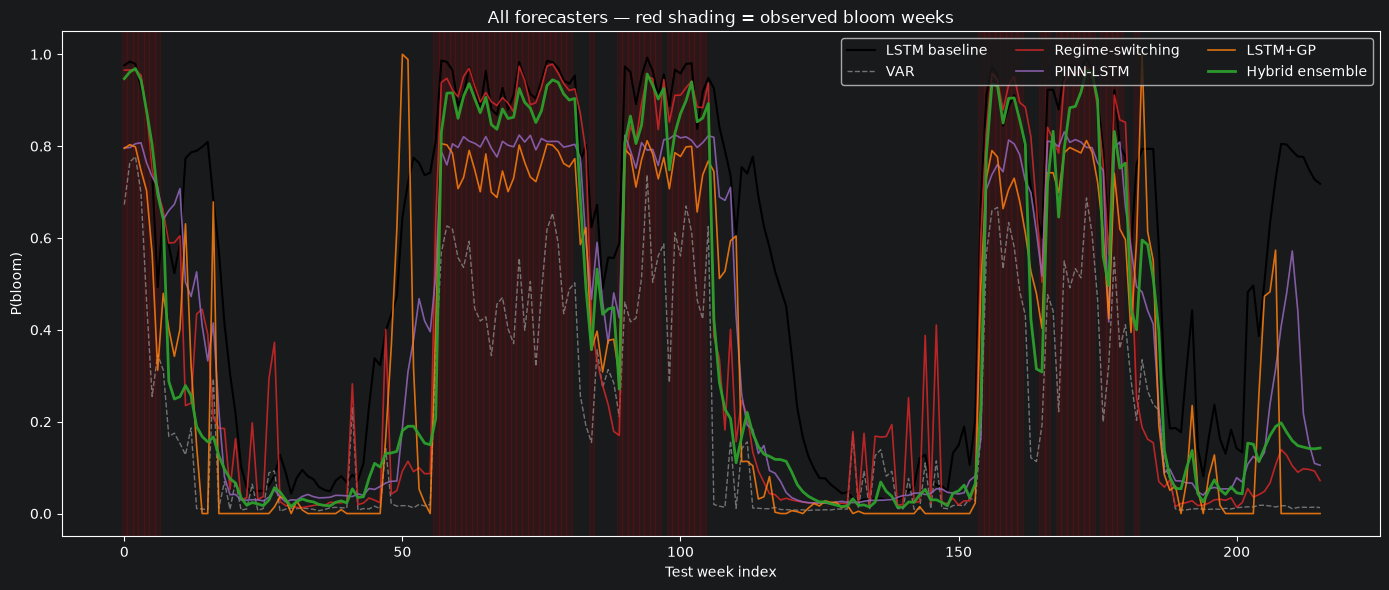

Saved: output_refactored/all_forecasters_comparison.png


In [7]:
# --- Visualize all probability streams together ---
fig, ax = plt.subplots(figsize=(14, 6))
t = np.arange(n_eval)
ax.plot(t, lstm_p_test,    color='black',    lw=1.5, label='LSTM baseline')
ax.plot(t, var_prob_eval,  color='#999999',  lw=1,  alpha=0.7, ls='--', label='VAR')
ax.plot(t, p_regime_blend, color='#d62728',  lw=1.2, alpha=0.85, label='Regime-switching')
ax.plot(t, pinn_bloom_pred,color='#9467bd',  lw=1.2, alpha=0.85, label='PINN-LSTM')
ax.plot(t, p_lstm_gp,      color='#ff7f0e',  lw=1.2, alpha=0.85, label='LSTM+GP')
ax.plot(t, blended,        color='#2ca02c',  lw=2,  alpha=0.95, label='Hybrid ensemble')
# True bloom events as background
for i, yv in enumerate(y_eval_full):
    if yv > 0.5:
        ax.axvspan(i-0.5, i+0.5, color='red', alpha=0.08)
ax.set_xlabel('Test week index'); ax.set_ylabel('P(bloom)')
ax.set_title('All forecasters — red shading = observed bloom weeks')
ax.legend(loc='upper right', ncol=3)
plt.tight_layout(); plt.savefig('output_refactored/all_forecasters_comparison.png', dpi=200); plt.show()
print('Saved: output_refactored/all_forecasters_comparison.png')


---

## Part 20: Supplementary Tables

Compiles the final publication-ready tables as a formatted Microsoft Word document (`.docx`) with consistent academic styling — Times New Roman, centered alignment, shaded header rows, and numbered captions — using `python-docx`. All point estimates are accompanied by uncertainty intervals so that model comparisons are reported with statistical rigor rather than single-number summaries.

* **Revised Table 3** — expanded model comparison (climatology, persistence, logistic regression, random forest, standalone LSTM, LSTM–EnKF hybrid) with 95% bootstrap confidence intervals on accuracy, precision, recall, F1, and Brier score, and Clopper–Pearson exact intervals on the onset hit rate.
* **Table S1** — EnKF Q-scaling sensitivity results from Part 19 (Experiment A).
* **Table S2** — EnKF ensemble-size sensitivity results from Part 19 (Experiment B).
* **Outputs:** `.docx` tables plus matching `.csv` exports in `output/` for downstream figure generation in Part 21.

In [8]:
!pip install docx
!pip install python-docx
!pip install scipy
import pandas as pd
from docx.shared import Pt
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from scipy import stats as sp_stats
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, brier_score_loss, roc_auc_score,
                             average_precision_score, precision_recall_curve,
                             confusion_matrix)

os.makedirs('output', exist_ok=True)


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def fmt_pct(val, ci_lo=None, ci_hi=None):
    """Format a proportion as percentage with optional CI."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    s = f"{val*100:.2f}%"
    if ci_lo is not None and ci_hi is not None:
        s += f" [{ci_lo*100:.1f}, {ci_hi*100:.1f}]"
    return s


def fmt_brier(val, ci_lo=None, ci_hi=None):
    """Format Brier score with optional CI."""
    if val is None:
        return "N/A"
    s = f"{val:.4f}"
    if ci_lo is not None and ci_hi is not None:
        s += f" [{ci_lo:.4f}, {ci_hi:.4f}]"
    return s


def fmt_onset(n_det, n_obs, ci_lo=None, ci_hi=None):
    """Format onset hit rate as fraction + percentage with optional CI."""
    if n_obs == 0:
        return "N/A"
    rate = n_det / n_obs
    s = f"{n_det}/{n_obs} ({rate*100:.0f}%)"
    if ci_lo is not None and ci_hi is not None:
        s += f" [{ci_lo*100:.0f}, {ci_hi*100:.0f}]"
    return s


def clopper_pearson(k, n, alpha=0.05):
    """Exact Clopper-Pearson binomial CI."""
    if n == 0:
        return 0, 0
    lo = sp_stats.beta.ppf(alpha / 2, k, n - k + 1) if k > 0 else 0.0
    hi = sp_stats.beta.ppf(1 - alpha / 2, k + 1, n - k) if k < n else 1.0
    return lo, hi


def style_table(table):
    """Apply consistent academic formatting to a python-docx table."""
    table.alignment = WD_TABLE_ALIGNMENT.CENTER

    # Set font size for all cells
    for row in table.rows:
        for cell in row.cells:
            for paragraph in cell.paragraphs:
                paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
                for run in paragraph.runs:
                    run.font.size = Pt(9)
                    run.font.name = 'Times New Roman'

    # Bold the header row
    for cell in table.rows[0].cells:
        for paragraph in cell.paragraphs:
            for run in paragraph.runs:
                run.font.bold = True

    # Light gray header shading
    for cell in table.rows[0].cells:
        shading = cell._element.get_or_add_tcPr()
        shd = shading.makeelement(qn('w:shd'), {
            qn('w:fill'): 'D9E2F3',
            qn('w:val'): 'clear'
        })
        shading.append(shd)


def add_caption(doc, text, bold_prefix=None):
    """Add a table caption paragraph."""
    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.LEFT
    p.paragraph_format.space_before = Pt(12)
    p.paragraph_format.space_after = Pt(4)
    if bold_prefix:
        run_b = p.add_run(bold_prefix)
        run_b.bold = True
        run_b.font.size = Pt(10)
        run_b.font.name = 'Times New Roman'
        run_n = p.add_run(text)
        run_n.font.size = Pt(10)
        run_n.font.name = 'Times New Roman'
    else:
        run_n = p.add_run(text)
        run_n.font.size = Pt(10)
        run_n.font.name = 'Times New Roman'


# ============================================================================
# COLLECT ALL MODEL RESULTS
# ============================================================================
print("--- Collecting results from Parts 17, 18, 19 ---\n")

# --- A. Regenerate LSTM baseline predictions ---
if lstm_p_test is None:
    raise RuntimeError("lstm_p_test not loaded — re-run the load cell.")
y_prob_lstm_raw = np.asarray(lstm_p_test).flatten()
y_test_flat     = np.asarray(y_eval_full).flatten().astype(int)

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test_flat, y_prob_lstm_raw)
fscore_arr = np.nan_to_num(2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-10))
best_ix = np.argmax(fscore_arr)
lstm_thresh = thresh_arr[best_ix] if best_ix < len(thresh_arr) else 0.5
y_pred_lstm_raw = (y_prob_lstm_raw >= lstm_thresh).astype(int)

# --- B. Regenerate Hybrid predictions ---
# enkf_hybrid_prob is already a 1-D point stream (collapsed in the load cell).
# Defensively re-collapse in case this cell is run against an older kernel
# state where enkf_hybrid_prob is still multi-dimensional.
def _as_point_stream(arr):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim <= 1:
        return arr.flatten()
    return arr.reshape(arr.shape[0], -1).mean(axis=1)

if enkf_hybrid_prob is not None and y_test_trimmed is not None:
    y_prob_hyb_raw = _as_point_stream(enkf_hybrid_prob)
    y_test_hyb_raw = np.asarray(y_test_trimmed).flatten().astype(int)

    # Final length guard: trim truth to the stream length if needed.
    if len(y_test_hyb_raw) != len(y_prob_hyb_raw):
        n = min(len(y_test_hyb_raw), len(y_prob_hyb_raw))
        y_prob_hyb_raw = y_prob_hyb_raw[-n:]
        y_test_hyb_raw = y_test_hyb_raw[-n:]
else:
    print("Skipping hybrid CIs - notebook 04b mc_preds / y_test_trimmed not found.")
    y_prob_hyb_raw = y_test_hyb_raw = None

# Only compute the PR-curve threshold when the hybrid stream exists. (The old
# code called precision_recall_curve unconditionally, so the skip branch above
# would still crash on the next line.)
if y_prob_hyb_raw is not None and y_test_hyb_raw is not None:
    prec_h, rec_h, thresh_h = precision_recall_curve(y_test_hyb_raw, y_prob_hyb_raw)
    fscore_h = np.nan_to_num(2 * prec_h * rec_h / (prec_h + rec_h + 1e-10))
    best_ix_h = np.argmax(fscore_h)
    hyb_thresh = thresh_h[best_ix_h] if best_ix_h < len(thresh_h) else 0.5
    y_pred_hyb_raw = (y_prob_hyb_raw >= hyb_thresh).astype(int)
else:
    hyb_thresh = 0.5
    y_pred_hyb_raw = None


# ============================================================================
# TABLE 3 (REVISED): EXPANDED MODEL COMPARISON WITH BOOTSTRAP CIs
# ============================================================================
print("=" * 80)
print("BUILDING REVISED TABLE 3")
print("=" * 80)

# Compute bootstrap CIs for LSTM and Hybrid
lstm_ci = bootstrap_classification_metrics(y_test_flat, y_pred_lstm_raw, y_prob_lstm_raw)
if y_pred_hyb_raw is not None:
    hybrid_ci = bootstrap_classification_metrics(y_test_hyb_raw, y_pred_hyb_raw, y_prob_hyb_raw)
else:
    hybrid_ci = None

# Onset stats
def get_onset(y_true, y_pred):
    onsets = np.where((y_true[:-1] == 0) & (y_true[1:] == 1))[0] + 1
    n_o = len(onsets)
    n_d = sum(y_pred[idx] == 1 for idx in onsets if idx < len(y_pred))
    return n_o, n_d

n_o_lstm, n_d_lstm = get_onset(y_test_flat, y_pred_lstm_raw)
n_o_hyb, n_d_hyb = get_onset(y_test_hyb_raw, y_pred_hyb_raw)

ci_onset_lstm = clopper_pearson(n_d_lstm, n_o_lstm)
ci_onset_hyb = clopper_pearson(n_d_hyb, n_o_hyb)

# Build rows for Table 3
table3_rows = []

# Simple baselines (from Part 17)
# Simple baselines (from Part 12) — with bootstrap CIs to match the LSTM row
if 'baseline_results' in locals() and baseline_results is not None:
    for name, res in baseline_results.items():
        n_o_b, n_d_b = res['n_onsets'], res['n_detected']
        ci_b = clopper_pearson(n_d_b, n_o_b) if n_o_b > 0 else (0, 0)

        # Bootstrap CIs if predictions are available; fall back to point estimates otherwise.
        if 'y_pred' in res and 'y_prob' in res:
            b_ci = bootstrap_classification_metrics(
                y_test_flat,
                np.asarray(res['y_pred']).astype(int),
                np.asarray(res['y_prob']).astype(float),
            )
            row = {
                'Model': name,
                'Accuracy':    fmt_pct(b_ci['Accuracy']['point'],  b_ci['Accuracy']['ci_lo'],  b_ci['Accuracy']['ci_hi']),
                'Precision':   fmt_pct(b_ci['Precision']['point'], b_ci['Precision']['ci_lo'], b_ci['Precision']['ci_hi']),
                'Recall':      fmt_pct(b_ci['Recall']['point'],    b_ci['Recall']['ci_lo'],    b_ci['Recall']['ci_hi']),
                'F1':          fmt_pct(b_ci['F1']['point'],        b_ci['F1']['ci_lo'],        b_ci['F1']['ci_hi']),
                'Brier Score': fmt_brier(b_ci['Brier']['point'],   b_ci['Brier']['ci_lo'],     b_ci['Brier']['ci_hi']),
                'FP': str(res['fp']),
                'FN': str(res['fn']),
                'Onset Hit Rate': fmt_onset(n_d_b, n_o_b, ci_b[0], ci_b[1]),
            }
        else:
            row = {
                'Model': name,
                'Accuracy':    fmt_pct(res['accuracy']),
                'Precision':   fmt_pct(res['precision']),
                'Recall':      fmt_pct(res['recall']),
                'F1':          fmt_pct(res['f1']),
                'Brier Score': fmt_brier(res['brier']),
                'FP': str(res['fp']),
                'FN': str(res['fn']),
                'Onset Hit Rate': fmt_onset(n_d_b, n_o_b, ci_b[0], ci_b[1]),
            }
        table3_rows.append(row)

# Standalone LSTM
cm_lstm = confusion_matrix(y_test_flat, y_pred_lstm_raw, labels=[0, 1])
tn_l, fp_l, fn_l, tp_l = cm_lstm.ravel()
table3_rows.append({
    'Model': 'Standalone LSTM',
    'Accuracy': fmt_pct(lstm_ci['Accuracy']['point'],
                        lstm_ci['Accuracy']['ci_lo'], lstm_ci['Accuracy']['ci_hi']),
    'Precision': fmt_pct(lstm_ci['Precision']['point'],
                         lstm_ci['Precision']['ci_lo'], lstm_ci['Precision']['ci_hi']),
    'Recall': fmt_pct(lstm_ci['Recall']['point'],
                      lstm_ci['Recall']['ci_lo'], lstm_ci['Recall']['ci_hi']),
    'F1': fmt_pct(lstm_ci['F1']['point'],
                  lstm_ci['F1']['ci_lo'], lstm_ci['F1']['ci_hi']),
    'Brier Score': fmt_brier(lstm_ci['Brier']['point'],
                             lstm_ci['Brier']['ci_lo'], lstm_ci['Brier']['ci_hi']),
    'FP': str(fp_l),
    'FN': str(fn_l),
    'Onset Hit Rate': fmt_onset(n_d_lstm, n_o_lstm, ci_onset_lstm[0], ci_onset_lstm[1])
})

# LSTM-EnKF Hybrid
cm_hyb = confusion_matrix(y_test_hyb_raw, y_pred_hyb_raw, labels=[0, 1])
tn_h, fp_h, fn_h, tp_h = cm_hyb.ravel()
table3_rows.append({
    'Model': 'LSTM–EnKF Hybrid',
    'Accuracy': fmt_pct(hybrid_ci['Accuracy']['point'],
                        hybrid_ci['Accuracy']['ci_lo'], hybrid_ci['Accuracy']['ci_hi']),
    'Precision': fmt_pct(hybrid_ci['Precision']['point'],
                         hybrid_ci['Precision']['ci_lo'], hybrid_ci['Precision']['ci_hi']),
    'Recall': fmt_pct(hybrid_ci['Recall']['point'],
                      hybrid_ci['Recall']['ci_lo'], hybrid_ci['Recall']['ci_hi']),
    'F1': fmt_pct(hybrid_ci['F1']['point'],
                  hybrid_ci['F1']['ci_lo'], hybrid_ci['F1']['ci_hi']),
    'Brier Score': fmt_brier(hybrid_ci['Brier']['point'],
                             hybrid_ci['Brier']['ci_lo'], hybrid_ci['Brier']['ci_hi']),
    'FP': str(fp_h),
    'FN': str(fn_h),
    'Onset Hit Rate': fmt_onset(n_d_hyb, n_o_hyb, ci_onset_hyb[0], ci_onset_hyb[1])
})

df_table3 = pd.DataFrame(table3_rows)
df_table3.to_csv('output/Table3_revised.csv', index=False)
print("Saved: output/Table3_revised.csv")
print(df_table3.to_string(index=False))


# ============================================================================
# TABLE S1: EnKF Q-SCALING SENSITIVITY
# ============================================================================
print("\n" + "=" * 80)
print("BUILDING TABLE S1: Q-SCALING SENSITIVITY")
print("=" * 80)

table_s1_rows = []
if 'sensitivity_results_q' in locals() and sensitivity_results_q:
    for qs, res in sorted(sensitivity_results_q.items()):
        n_o, n_d = res['n_onsets'], res['n_det']
        ci_o = clopper_pearson(n_d, n_o) if n_o > 0 else (0, 0)
        table_s1_rows.append({
            'Q Scale Factor': f"{qs:.2f}x" + (" *" if qs == 1.0 else ""),
            'Accuracy (%)': f"{res['acc']*100:.2f}",
            'Precision (%)': f"{res['prec']*100:.2f}",
            'Recall (%)': f"{res['rec']*100:.2f}",
            'F1 (%)': f"{res['f1']*100:.2f}",
            'Brier Score': f"{res['brier']:.4f}",
            'Onset Hit Rate': fmt_onset(n_d, n_o, ci_o[0], ci_o[1]),
            'Threshold': f"{res['threshold']:.3f}"
        })

s1_columns = ['Q Scale Factor', 'Accuracy (%)', 'Precision (%)', 'Recall (%)',
              'F1 (%)', 'Brier Score', 'Onset Hit Rate', 'Threshold']
df_s1 = pd.DataFrame(table_s1_rows, columns=s1_columns)
df_s1.to_csv('output/TableS1_Q_sensitivity.csv', index=False)
print("Saved: output/TableS1_Q_sensitivity.csv")
if len(df_s1) > 0:
    print(df_s1.to_string(index=False))
else:
    print("  (empty - EnKF-preprocessor sensitivity requires rerunning notebooks 01-04 per Q setting)")


# ============================================================================
# TABLE S2: ENSEMBLE SIZE SENSITIVITY
# ============================================================================
print("\n" + "=" * 80)
print("BUILDING TABLE S2: ENSEMBLE SIZE SENSITIVITY")
print("=" * 80)

table_s2_rows = []
if 'sensitivity_results_n' in locals() and sensitivity_results_n:
    for n_ens, res in sorted(sensitivity_results_n.items()):
        n_o, n_d = res['n_onsets'], res['n_det']
        ci_o = clopper_pearson(n_d, n_o) if n_o > 0 else (0, 0)
        table_s2_rows.append({
            'Ensemble Size (N)': f"{n_ens}" + (" *" if n_ens == 50 else ""),
            'Accuracy (%)': f"{res['acc']*100:.2f}",
            'Precision (%)': f"{res['prec']*100:.2f}",
            'Recall (%)': f"{res['rec']*100:.2f}",
            'F1 (%)': f"{res['f1']*100:.2f}",
            'Brier Score': f"{res['brier']:.4f}",
            'Onset Hit Rate': fmt_onset(n_d, n_o, ci_o[0], ci_o[1]),
            'Threshold': f"{res['threshold']:.3f}"
        })

s2_columns = ['Ensemble Size (N)', 'Accuracy (%)', 'Precision (%)', 'Recall (%)',
              'F1 (%)', 'Brier Score', 'Onset Hit Rate', 'Threshold']
df_s2 = pd.DataFrame(table_s2_rows, columns=s2_columns)
df_s2.to_csv('output/TableS2_N_sensitivity.csv', index=False)
print("Saved: output/TableS2_N_sensitivity.csv")
if len(df_s2) > 0:
    print(df_s2.to_string(index=False))
else:
    print("  (empty - EnKF-preprocessor sensitivity requires rerunning notebooks 01-04 per N setting)")


# ============================================================================
# TABLE S3: FULL BOOTSTRAP CI DETAILS
# ============================================================================
print("\n" + "=" * 80)
print("BUILDING TABLE S3: BOOTSTRAP CI DETAILS")
print("=" * 80)

s3_rows = []
for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1', 'Brier']:
    row = {'Metric': metric_name}

    # LSTM
    r = lstm_ci[metric_name]
    if metric_name == 'Brier':
        row['LSTM Point'] = f"{r['point']:.4f}"
        row['LSTM 95% CI'] = f"[{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]"
        row['LSTM Width'] = f"{(r['ci_hi'] - r['ci_lo']):.4f}"
    else:
        row['LSTM Point'] = f"{r['point']*100:.2f}%"
        row['LSTM 95% CI'] = f"[{r['ci_lo']*100:.1f}%, {r['ci_hi']*100:.1f}%]"
        row['LSTM Width'] = f"{(r['ci_hi'] - r['ci_lo'])*100:.1f}pp"

    # Hybrid
    r = hybrid_ci[metric_name]
    if metric_name == 'Brier':
        row['Hybrid Point'] = f"{r['point']:.4f}"
        row['Hybrid 95% CI'] = f"[{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]"
        row['Hybrid Width'] = f"{(r['ci_hi'] - r['ci_lo']):.4f}"
    else:
        row['Hybrid Point'] = f"{r['point']*100:.2f}%"
        row['Hybrid 95% CI'] = f"[{r['ci_lo']*100:.1f}%, {r['ci_hi']*100:.1f}%]"
        row['Hybrid Width'] = f"{(r['ci_hi'] - r['ci_lo'])*100:.1f}pp"

    # Overlap check
    lo_l = lstm_ci[metric_name]['ci_lo']
    hi_l = lstm_ci[metric_name]['ci_hi']
    lo_h = hybrid_ci[metric_name]['ci_lo']
    hi_h = hybrid_ci[metric_name]['ci_hi']
    row['CIs Overlap?'] = 'Yes' if (lo_l < hi_h and lo_h < hi_l) else 'No'

    s3_rows.append(row)

# Add onset hit rate row
ohr_l_lo, ohr_l_hi = ci_onset_lstm
ohr_h_lo, ohr_h_hi = ci_onset_hyb
rate_l = n_d_lstm / n_o_lstm if n_o_lstm > 0 else 0
rate_h = n_d_hyb / n_o_hyb if n_o_hyb > 0 else 0
s3_rows.append({
    'Metric': f'Onset HR (n={n_o_lstm})',
    'LSTM Point': f"{rate_l*100:.0f}%",
    'LSTM 95% CI': f"[{ohr_l_lo*100:.0f}%, {ohr_l_hi*100:.0f}%]",
    'LSTM Width': f"{(ohr_l_hi - ohr_l_lo)*100:.0f}pp",
    'Hybrid Point': f"{rate_h*100:.0f}%",
    'Hybrid 95% CI': f"[{ohr_h_lo*100:.0f}%, {ohr_h_hi*100:.0f}%]",
    'Hybrid Width': f"{(ohr_h_hi - ohr_h_lo)*100:.0f}pp",
    'CIs Overlap?': 'Yes' if (ohr_l_lo < ohr_h_hi and ohr_h_lo < ohr_l_hi) else 'No'
})

df_s3 = pd.DataFrame(s3_rows)
df_s3.to_csv('output/TableS3_bootstrap_CIs.csv', index=False)
print("Saved: output/TableS3_bootstrap_CIs.csv")
print(df_s3.to_string(index=False))


# ============================================================================
# TABLE S4: PROPAGATOR SENSITIVITY (Experiment C)
# ============================================================================
print("\n" + "=" * 80)
print("BUILDING TABLE S4: PROPAGATOR SENSITIVITY")
print("=" * 80)

table_s4_rows = []
if 'sensitivity_results_propagator' in locals() and sensitivity_results_propagator:
    # Preferred display order so the random-walk baseline is the first row
    propagator_order = ['RandomWalk', 'AR1', 'VAR1', 'SeasonalAR1']
    ordered_keys = [k for k in propagator_order if k in sensitivity_results_propagator]
    # Anything else (e.g. custom propagators) appended in JSON order
    ordered_keys += [k for k in sensitivity_results_propagator if k not in propagator_order]

    for label in ordered_keys:
        res = sensitivity_results_propagator[label]
        n_o, n_d = int(res['n_onsets']), int(res['n_det'])
        ci_o = clopper_pearson(n_d, n_o) if n_o > 0 else (0, 0)
        row = {
            'Propagator':      f"{label}" + (" *" if label == 'RandomWalk' else ""),
            'Accuracy (%)':    f"{res['acc']*100:.2f}",
            'Precision (%)':   f"{res['prec']*100:.2f}",
            'Recall (%)':      f"{res['rec']*100:.2f}",
            'F1 (%)':          f"{res['f1']*100:.2f}",
            'Brier Score':     f"{res['brier']:.4f}",
            'Onset Hit Rate':  fmt_onset(n_d, n_o, ci_o[0], ci_o[1]),
            'Threshold':       f"{res['threshold']:.3f}",
        }
        # Propagator-specific diagnostic columns (only populated where relevant)
        row['Q trace'] = f"{res.get('Q_trace', float('nan')):.3e}" if res.get('Q_trace') is not None else ''
        if 'spectral_radius' in res and res['spectral_radius'] is not None:
            row['VAR(1) ρ(A)'] = f"{res['spectral_radius']:.3f}"
        table_s4_rows.append(row)

df_s4 = pd.DataFrame(table_s4_rows)
df_s4.to_csv('output/TableS4_propagator_sensitivity.csv', index=False)
print("Saved: output/TableS4_propagator_sensitivity.csv")
if len(df_s4) > 0:
    print(df_s4.to_string(index=False))
else:
    print("  (empty — run notebook 05 Part 20 to generate propagator sensitivity results)")


# ============================================================================
# TABLE S5: BRIER SCORE DECOMPOSITION (Murphy 1973; Ferro & Fricker 2012)
# ============================================================================
# Decomposes the Brier score into reliability (calibration error), resolution
# (forecast informativeness vs. climatology), and uncertainty (irreducible
# base-rate variance) for both the standalone LSTM and the LSTM-EnKF hybrid.
# Identity: BS = REL - RES + UNC (exact for binned predictions).
# Ferro & Fricker debiased forms remove finite-sample bias in REL and RES.
print("\n" + "=" * 80)
print("BUILDING TABLE S5: BRIER SCORE DECOMPOSITION")
print("=" * 80)

# brier_decomposition.py should sit alongside enkf_utils.py / lstm_utils.py
try:
    from brier_decomposition import brier_decomposition, format_decomposition_summary
except ImportError as e:
    raise ImportError(
        "Could not import brier_decomposition. Place brier_decomposition.py "
        "in the same directory as the other utility modules (next to "
        "enkf_utils.py / lstm_utils.py)."
    ) from e

decomp_results = {}

# --- Standalone LSTM ---
if 'y_prob_lstm_raw' in locals() and 'y_test_flat' in locals():
    decomp_results['Standalone LSTM'] = brier_decomposition(
        y_test_flat, y_prob_lstm_raw, n_bins=10, strategy='quantile',
    )
    print(format_decomposition_summary(decomp_results['Standalone LSTM'],
                                       'Standalone LSTM'))

# --- LSTM-EnKF Hybrid ---
if 'y_prob_hyb_raw' in locals() and y_prob_hyb_raw is not None \
        and 'y_test_hyb_raw' in locals() and y_test_hyb_raw is not None:
    decomp_results['LSTM-EnKF Hybrid'] = brier_decomposition(
        y_test_hyb_raw, y_prob_hyb_raw, n_bins=10, strategy='quantile',
    )
    print(format_decomposition_summary(decomp_results['LSTM-EnKF Hybrid'],
                                       'LSTM-EnKF Hybrid'))

# --- Build comparison table ---
table_s5_rows = []
for model_name, r in decomp_results.items():
    bss = 1.0 - r['brier'] / r['uncertainty'] if r['uncertainty'] > 0 else float('nan')
    table_s5_rows.append({
        'Model':                      model_name,
        'Brier (raw)':                f"{r['brier']:.4f}",
        'Brier (binned)':             f"{r['brier_binned']:.4f}",
        'Reliability (REL)':          f"{r['reliability']:.4f}",
        'REL (Ferro-Fricker)':        f"{r['reliability_debiased']:.4f}",
        'Resolution (RES)':           f"{r['resolution']:.4f}",
        'RES (Ferro-Fricker)':        f"{r['resolution_debiased']:.4f}",
        'Uncertainty (UNC)':          f"{r['uncertainty']:.4f}",
        'Brier Skill Score':          f"{bss:.4f}",
        'REL / UNC':                  f"{r['reliability']/r['uncertainty']:.3f}",
        'RES / UNC':                  f"{r['resolution']/r['uncertainty']:.3f}",
        'n':                          int(r['n_total']),
        'Non-empty bins':             int(r['n_bins_used']),
    })

df_s5 = pd.DataFrame(table_s5_rows)
df_s5.to_csv('output/TableS5_brier_decomposition.csv', index=False)
print("Saved: output/TableS5_brier_decomposition.csv")
if len(df_s5) > 0:
    print(df_s5.to_string(index=False))


# ============================================================================
# TABLE S6: PER-BIN RELIABILITY DIAGNOSTIC (LSTM-EnKF Hybrid)
# ============================================================================
# Per-bin contributions to REL and RES — locates where in the probability
# range the hybrid's calibration error originates. Companion to the
# reliability diagram in Figure 5.
print("\n" + "=" * 80)
print("BUILDING TABLE S6: PER-BIN RELIABILITY DIAGNOSTIC (HYBRID)")
print("=" * 80)

if 'LSTM-EnKF Hybrid' in decomp_results:
    bt = decomp_results['LSTM-EnKF Hybrid']['bin_table'].copy()
    # Format for the supplementary table
    bt['Bin range'] = bt.apply(
        lambda r: f"[{r['edge_lo']:.2f}, {r['edge_hi']:.2f}]", axis=1)
    table_s6 = pd.DataFrame({
        'Bin':            bt['bin'].astype(int) + 1,
        'Predicted range': bt['Bin range'],
        'n':              bt['n_k'].astype(int),
        'Mean pred. prob.': bt['mean_pred'].map(lambda v: f"{v:.3f}"),
        'Observed freq.':   bt['obs_freq'].map(lambda v: f"{v:.3f}"),
        'Contrib. to REL':  bt['rel_contrib'].map(lambda v: f"{v:.5f}"),
        'Contrib. to RES':  bt['res_contrib'].map(lambda v: f"{v:.5f}"),
    })
    table_s6.to_csv('output/TableS6_brier_bins_hybrid.csv', index=False)
    print("Saved: output/TableS6_brier_bins_hybrid.csv")
    print(table_s6.to_string(index=False))

    # Persist raw per-bin frame (with all columns) for the figure cell to pick up
    bt.to_csv('output/_brier_bins_hybrid_raw.csv', index=False)

    # Same for LSTM if available, for the comparison figure
    if 'Standalone LSTM' in decomp_results:
        decomp_results['Standalone LSTM']['bin_table'].to_csv(
            'output/_brier_bins_lstm_raw.csv', index=False)
else:
    print("  Hybrid decomposition unavailable — skipping per-bin table.")



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Collecting results from Parts 17, 18, 19 ---

BUILDING REVISED TABLE 3



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Saved: output/Table3_revised.csv
           Model            Accuracy           Precision              Recall                  F1             Brier Score FP FN       Onset Hit Rate
     Climatology 67.59% [61.6, 74.1]    0.00% [nan, nan]    0.00% [0.0, 0.0]    0.00% [nan, nan] 0.2276 [0.1953, 0.2624]  0 70   0/9.0 (0%) [0, 34]
     Persistence 90.74% [86.6, 94.4] 85.71% [76.8, 93.3] 85.71% [77.0, 93.1] 85.71% [79.0, 91.6] 0.0926 [0.0556, 0.1343] 10 10   0/9.0 (0%) [0, 34]
    Logistic Reg 86.57% [81.9, 90.7] 72.53% [63.2, 81.7] 94.29% [88.6, 98.7] 81.99% [75.2, 88.1] 0.1308 [0.1016, 0.1638] 25  4 6/9.0 (67%) [30, 93]
   Random Forest 89.81% [85.6, 93.5] 78.57% [69.1, 86.9] 94.29% [88.2, 98.7] 85.71% [79.4, 91.4] 0.0815 [0.0637, 0.1022] 18  4 5/9.0 (56%) [21, 86]
 Standalone LSTM 92.13% [88.0, 95.4] 89.55% [81.6, 96.2] 85.71% [77.4, 93.5] 87.59% [81.4, 93.2] 0.1736 [0.1419, 0.2081]  7 10    3/9 (33%) [7, 70]
LSTM–EnKF Hybrid 87.96% [83.3, 92.1] 80.56% [71.0, 89.5] 82.86% [73.8, 91.3] 81

## Part 21: Supplementary Table Figures

Renders the supplementary tables from Part 20 as publication-quality figures for readers who prefer visual summaries. Values and confidence intervals are parsed directly from the exported `.csv` files, so the figures remain consistent with the tabulated results by construction.

* **Figure — Revised Table 3 (multi-metric):** horizontal bar chart of accuracy, precision, recall, and F1 across all six models, with 95% bootstrap CI error bars.
* **Figure — Brier score and onset detection:** paired panels showing probabilistic calibration (Brier) and bloom-onset hit rate with Clopper–Pearson intervals.
* **Figure — Table S1 (Q-scaling):** metric trajectories across the 0.25×–5× `Q` sweep, with the baseline configuration marked.
* **Figure — Table S2 (ensemble size):** metric trajectories across `N ∈ {25, 50, 100, 200}`, with the baseline marked.
* **Style:** serif typography (Times New Roman), 300 dpi, saved as both PNG and PDF to `output/` for direct inclusion in the manuscript.

--- Figure: Revised Table 3 ---
  Saved: output/Fig_Table3_revised.png


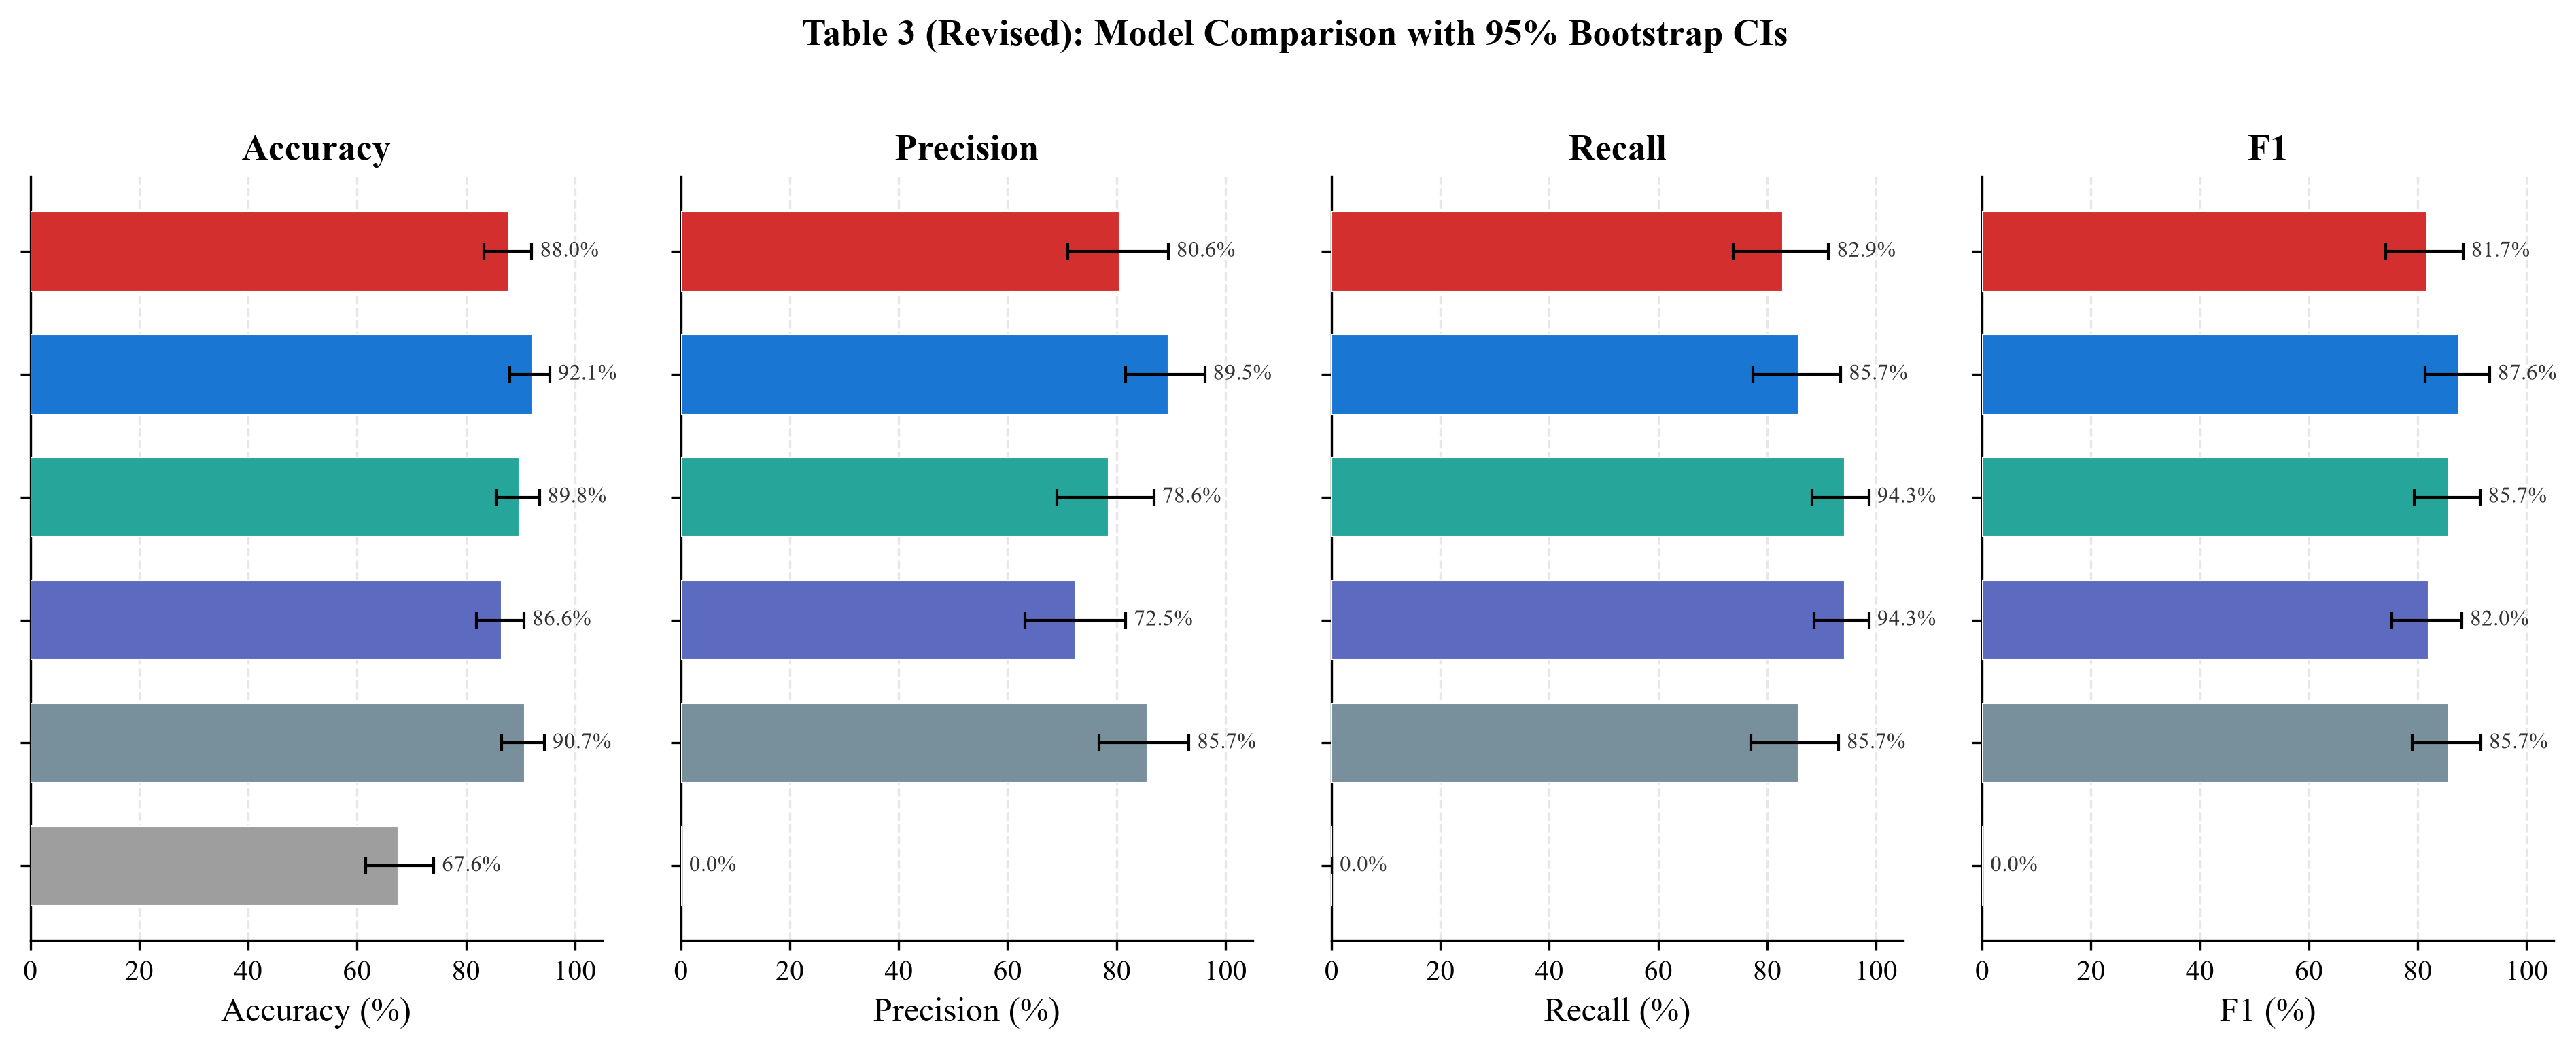

--- Figure: Brier Score + Onset Hit Rate ---
  Saved: output/Fig_Brier_Onset.png


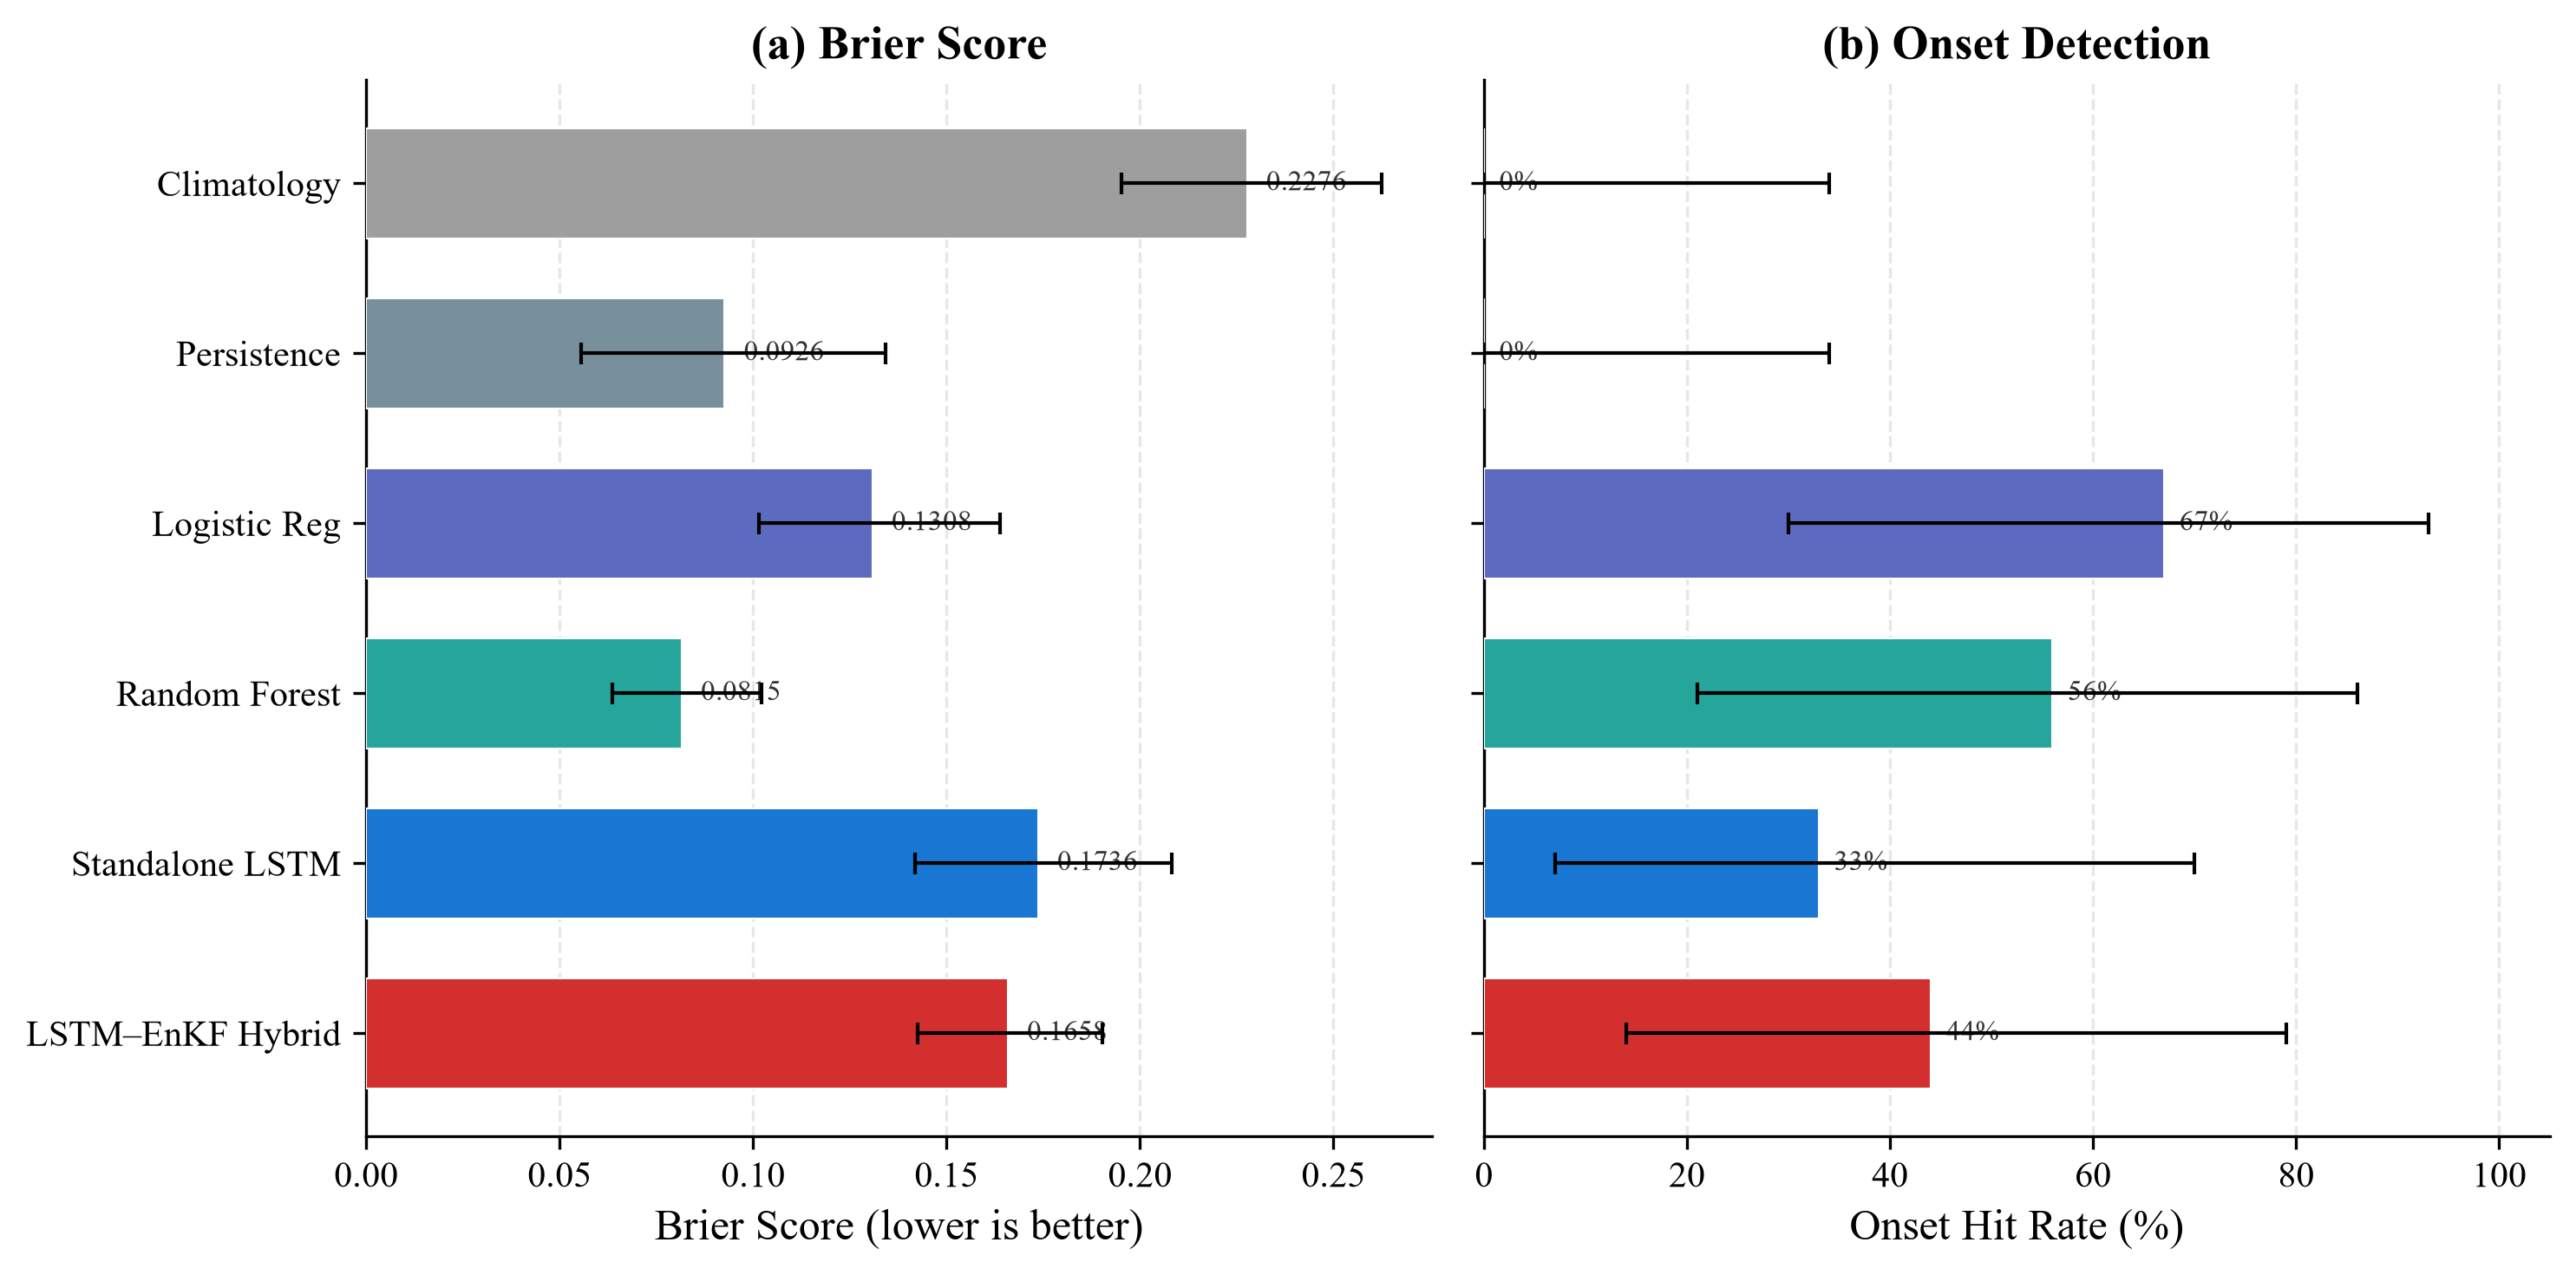

--- Figure: Table S1 (Q-scaling) ---
  TableS1 is empty — skipping. Run Part 19 first.
--- Figure: Table S2 (Ensemble size) ---
  TableS2 is empty — skipping. Run Part 19 first.
--- Figure: Table S3 (Bootstrap CI forest plot) ---
  Saved: output/Fig_TableS3_forest_plot.png


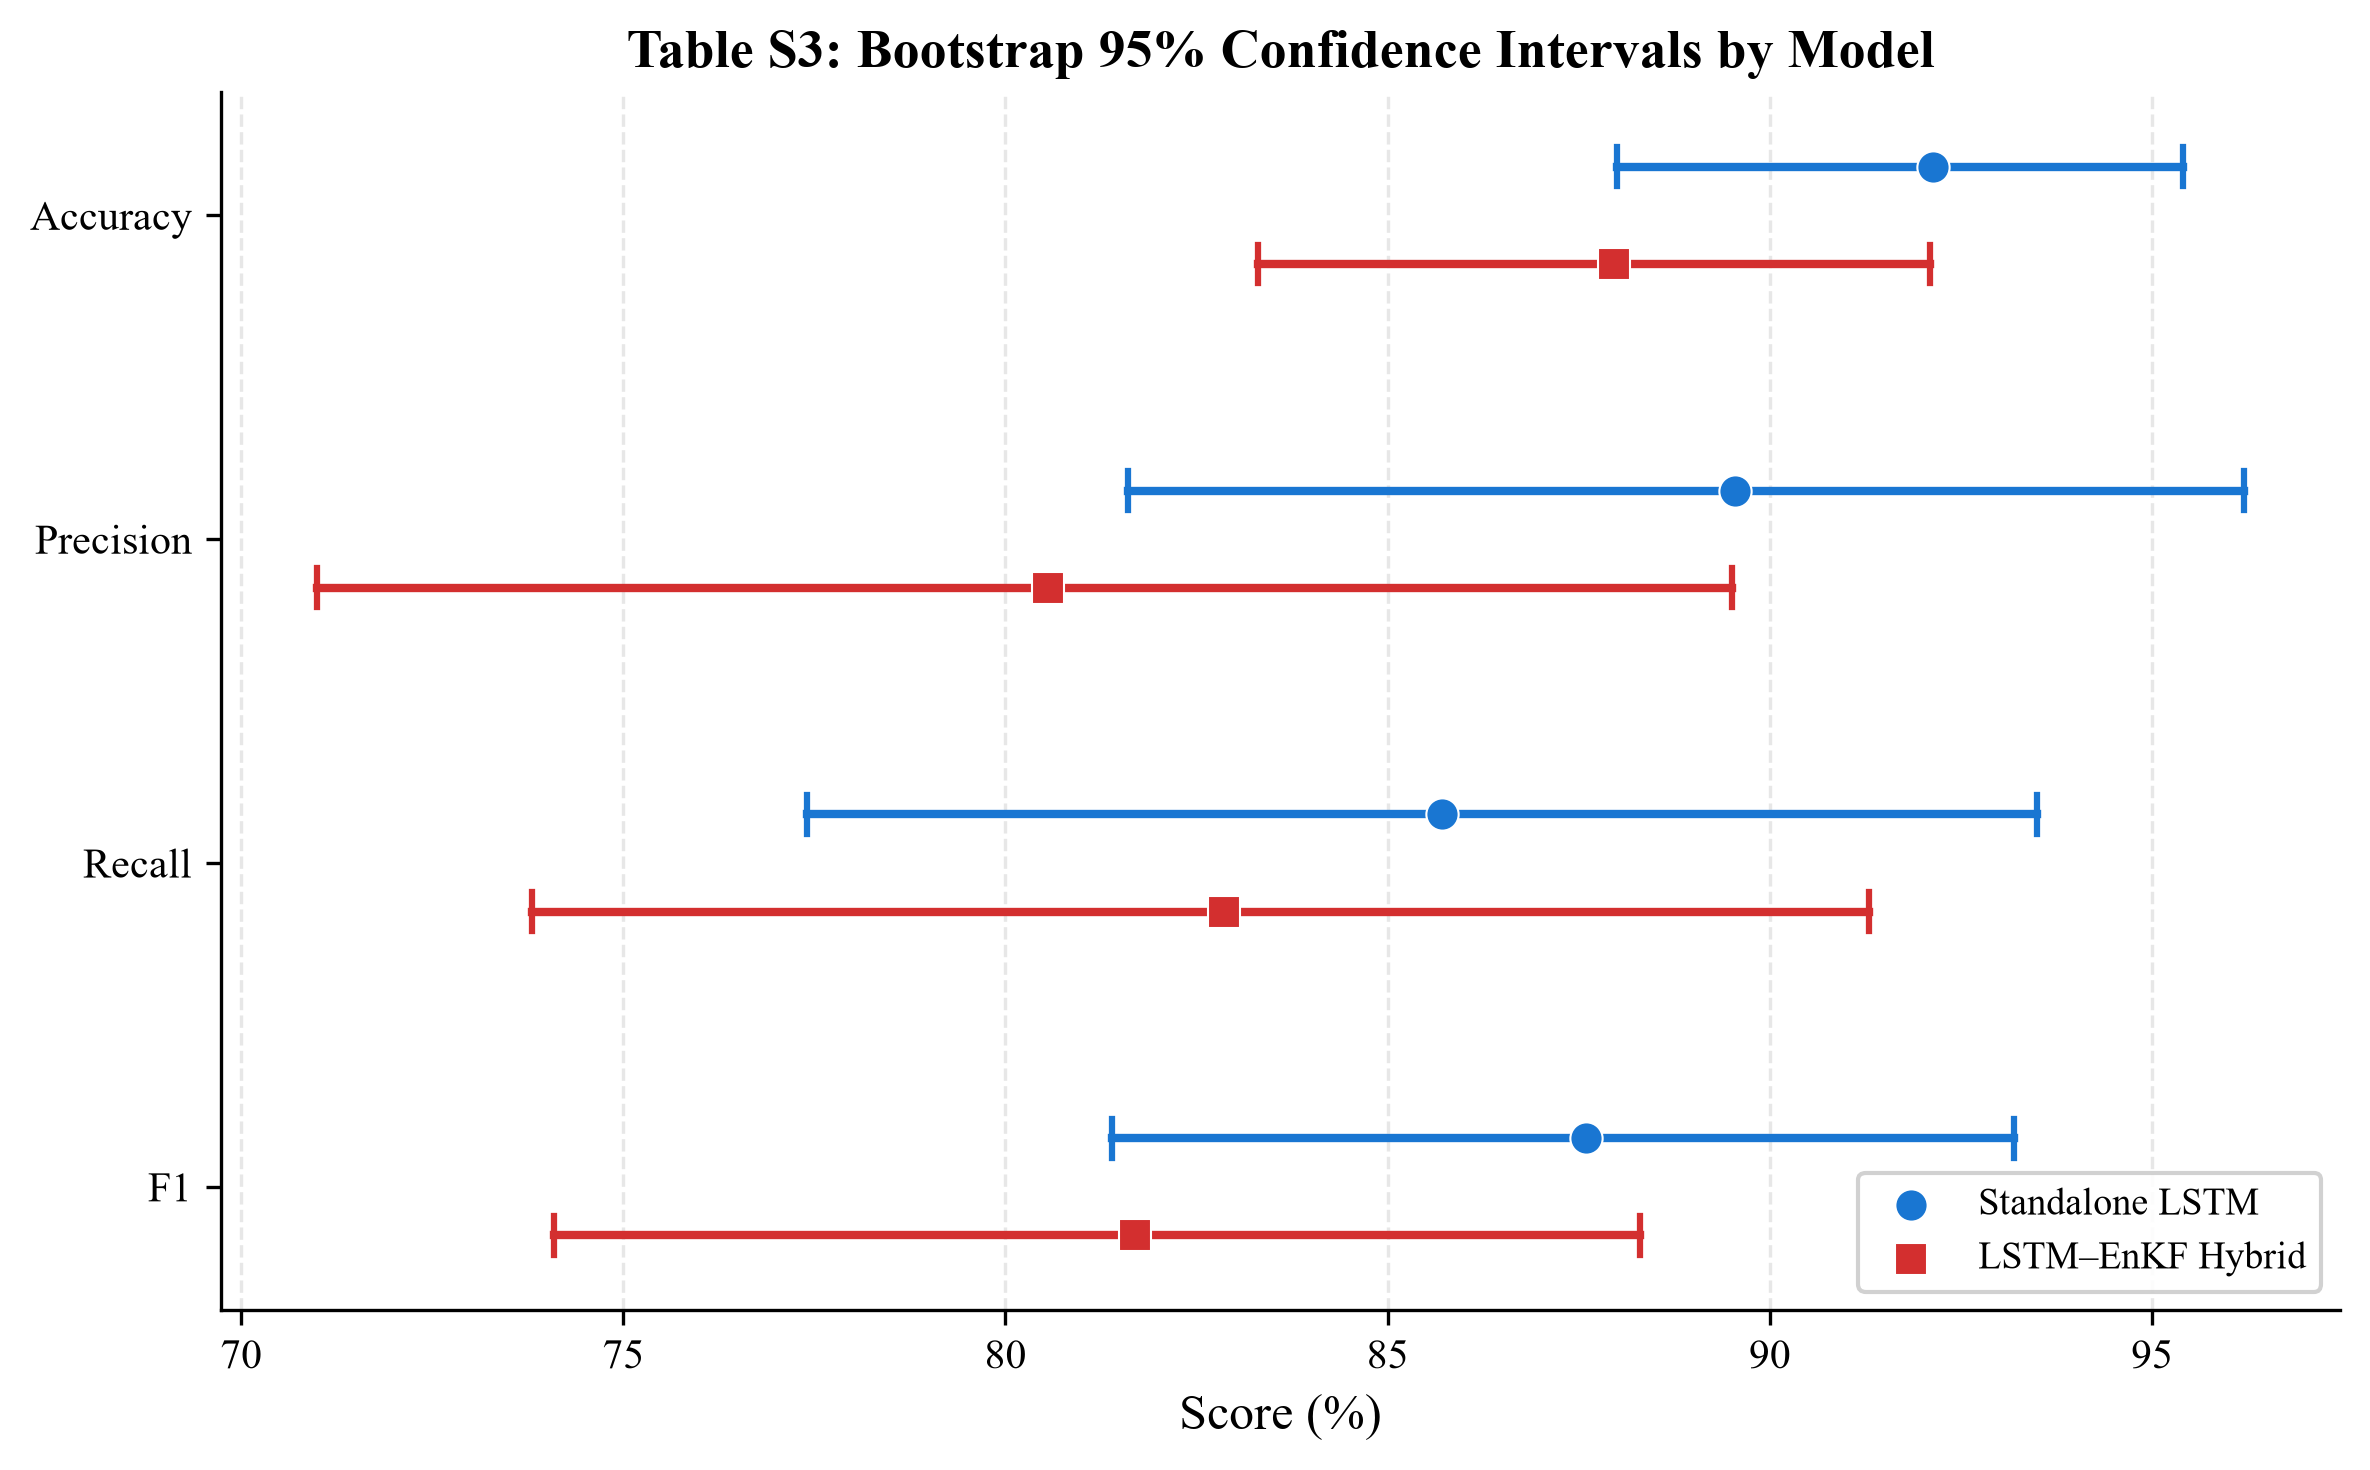

  Saved: output/Fig_TableS3_onset_CI.png


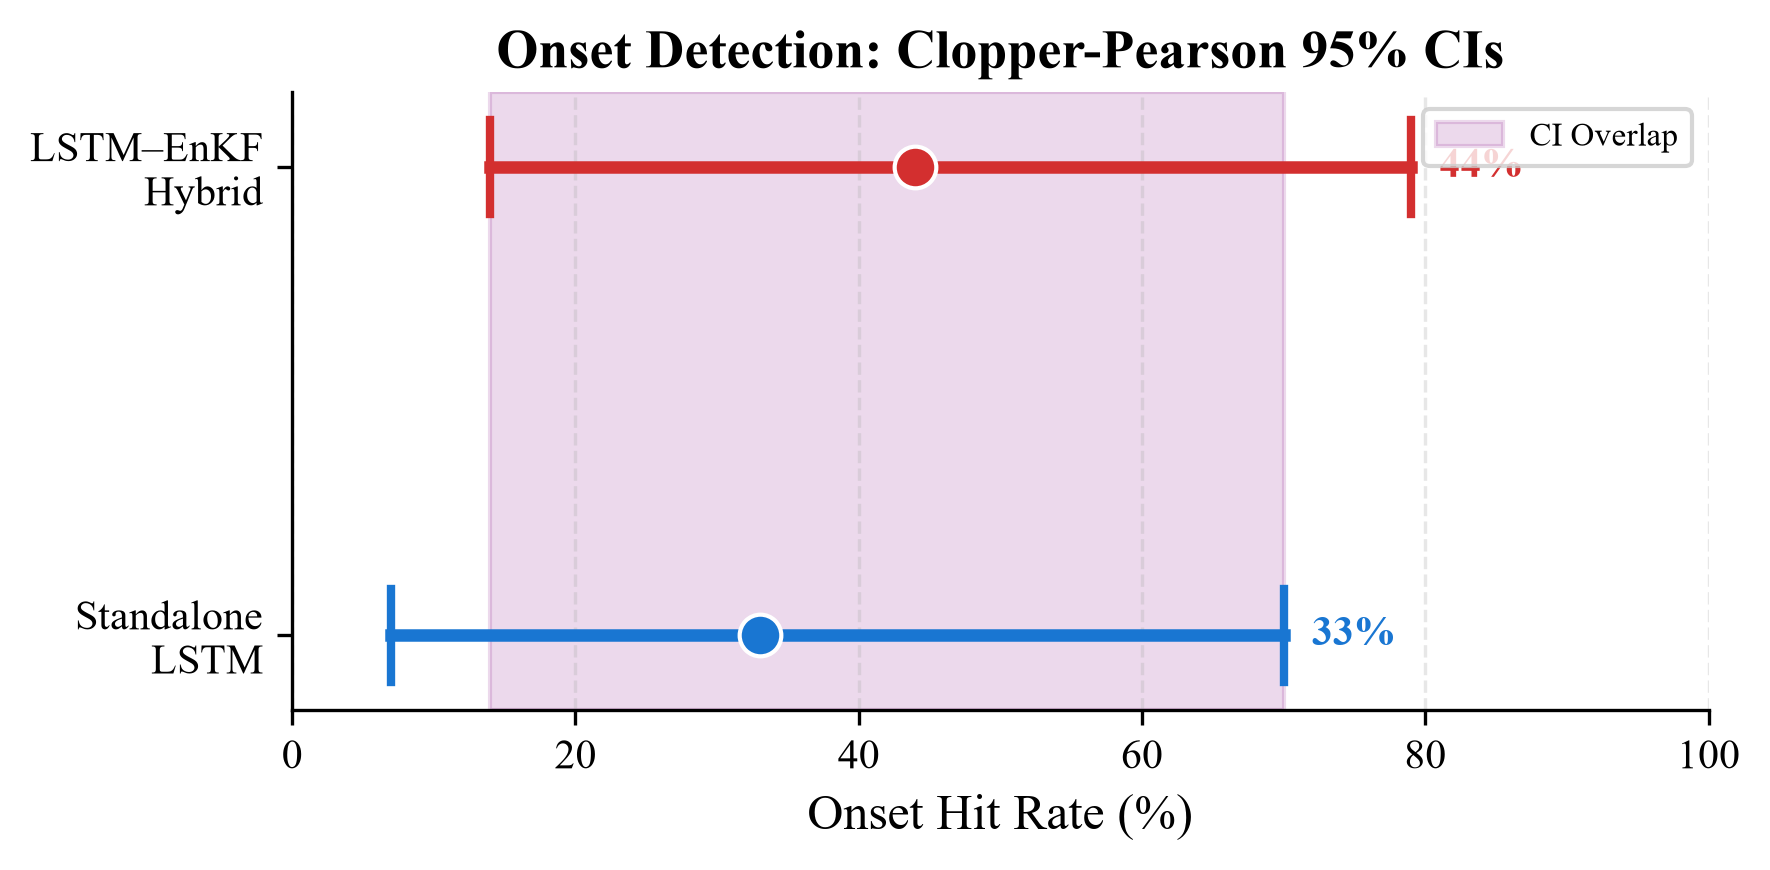

--- Figure: Table S4 (propagator sensitivity) ---
  Saved: output/Fig_TableS4_propagator.png


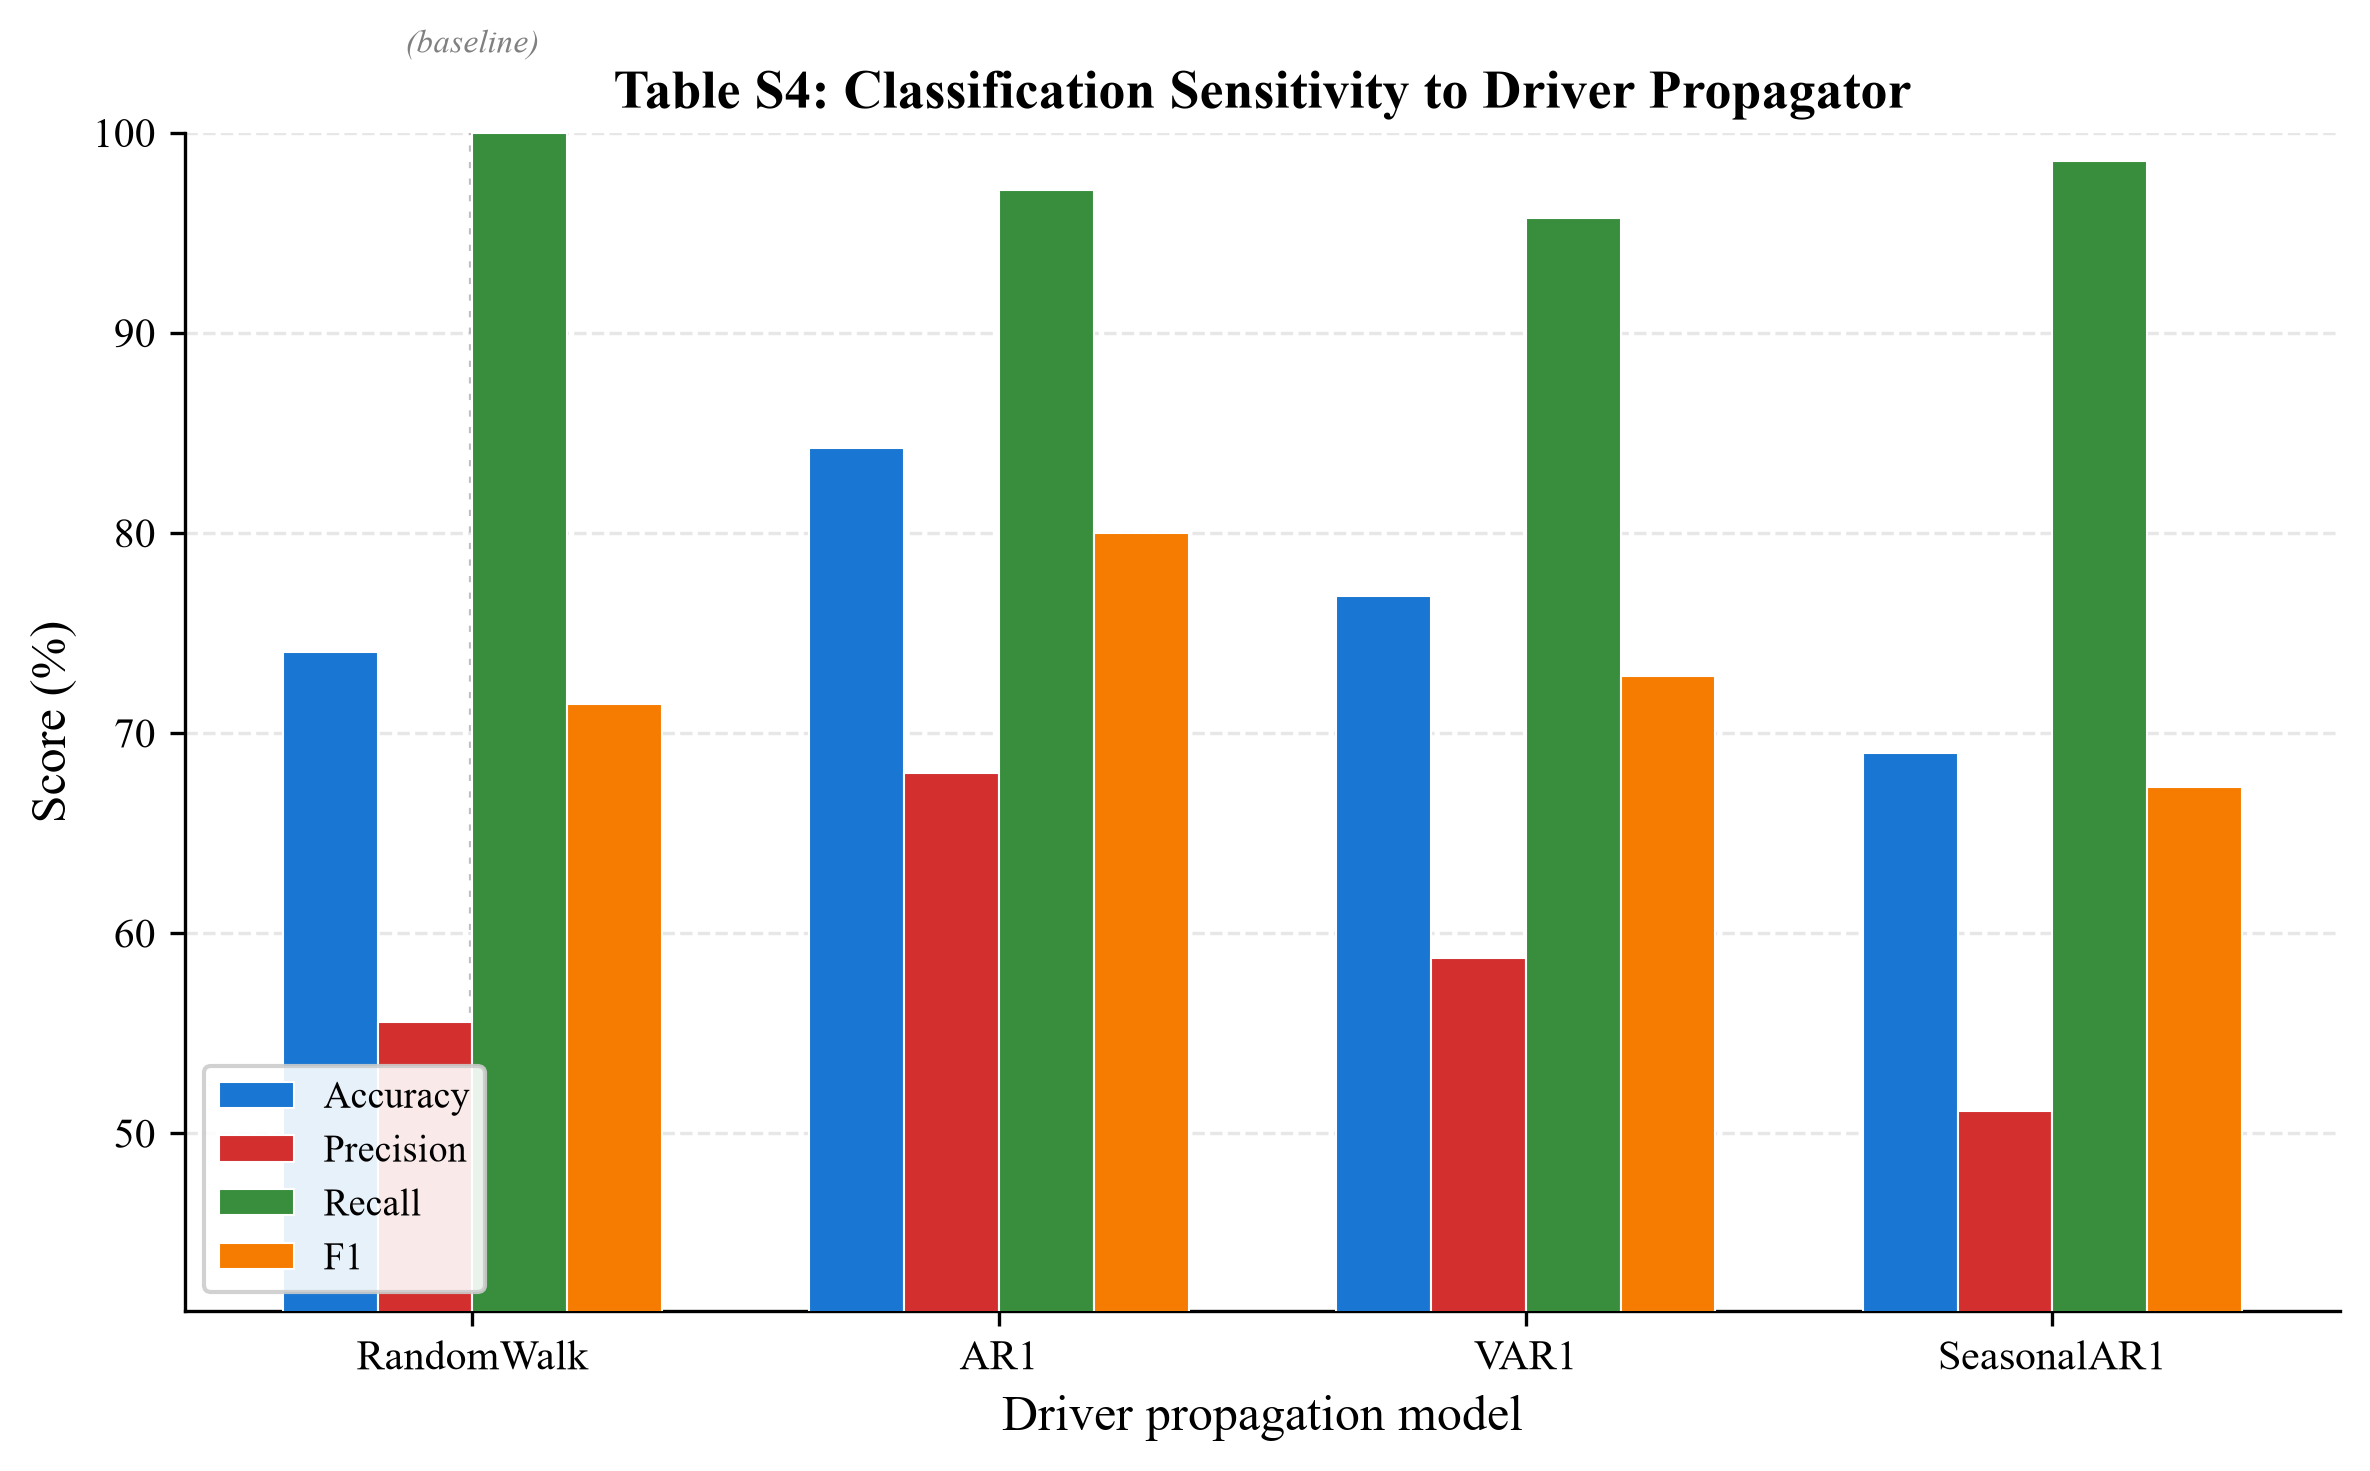

  Saved: output/Fig_TableS4_Brier.png


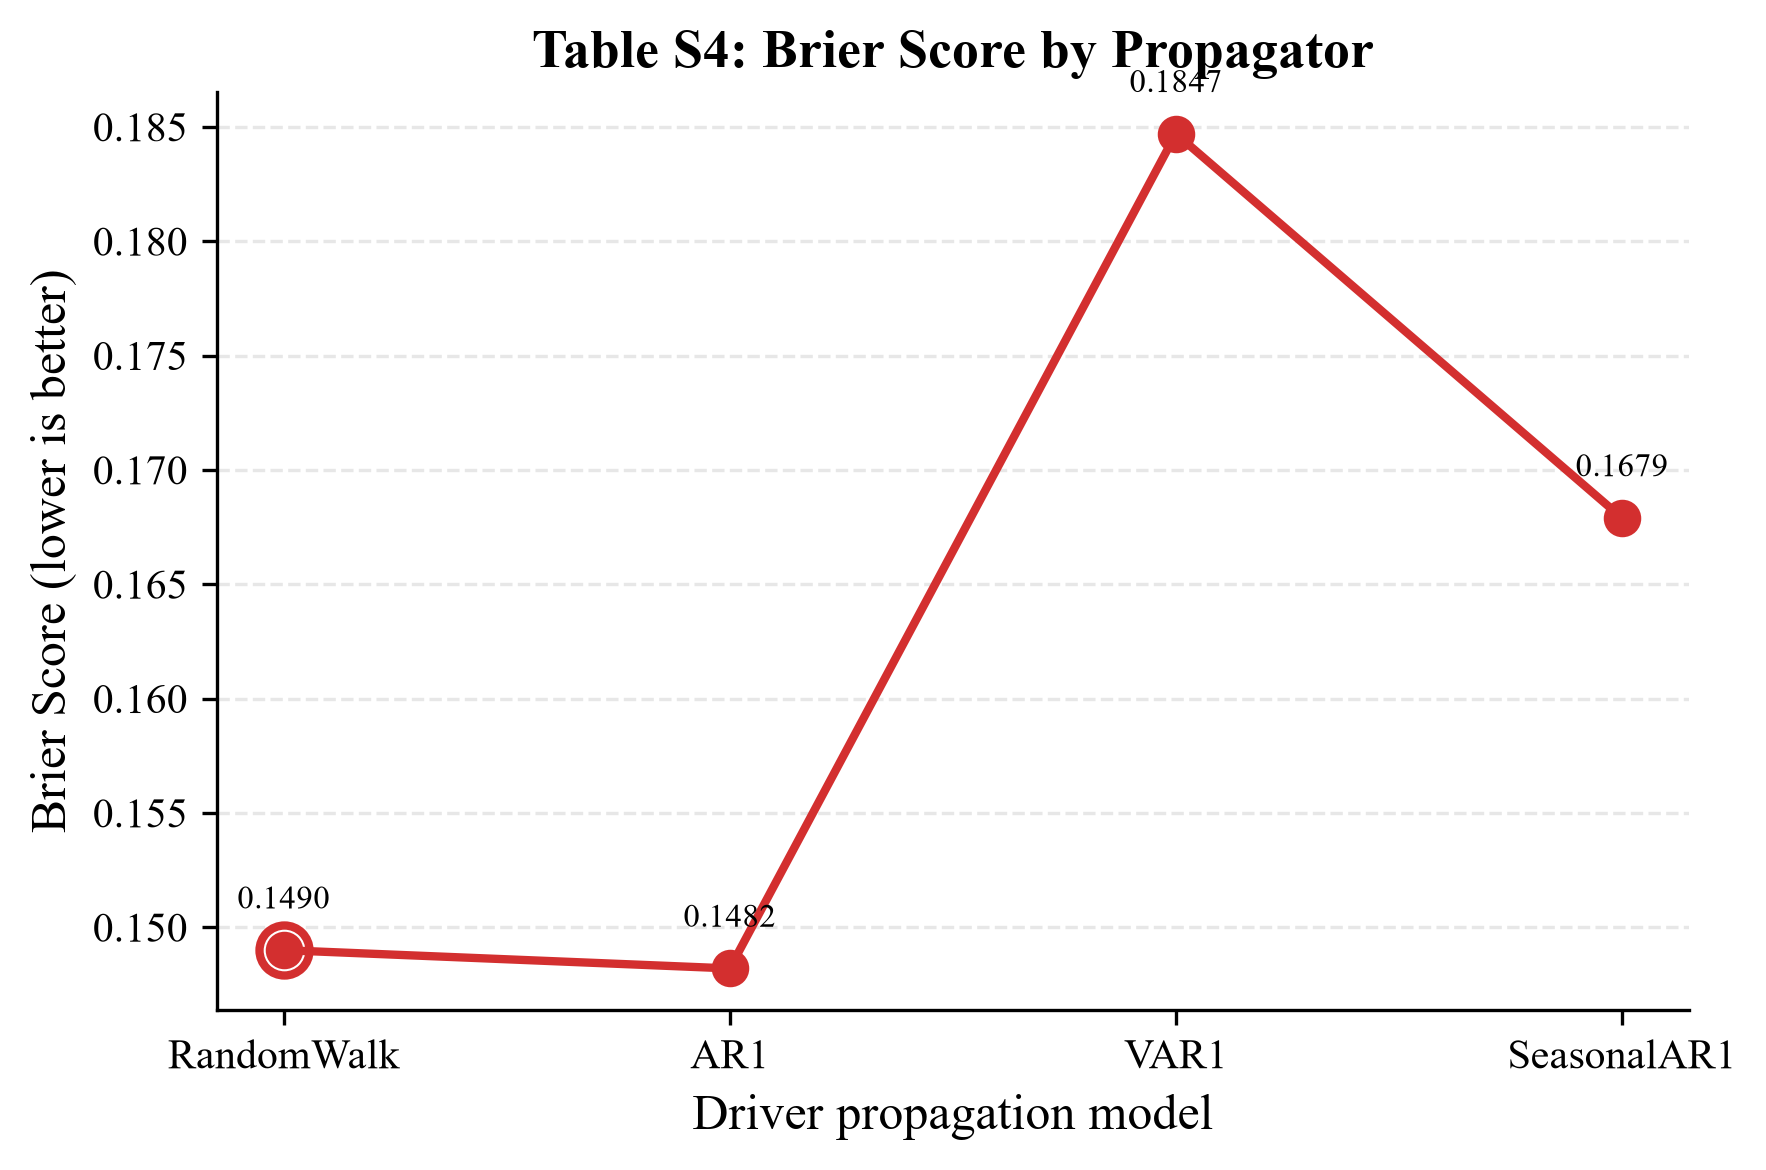

  Saved: output/Fig_TableS4_onset.png


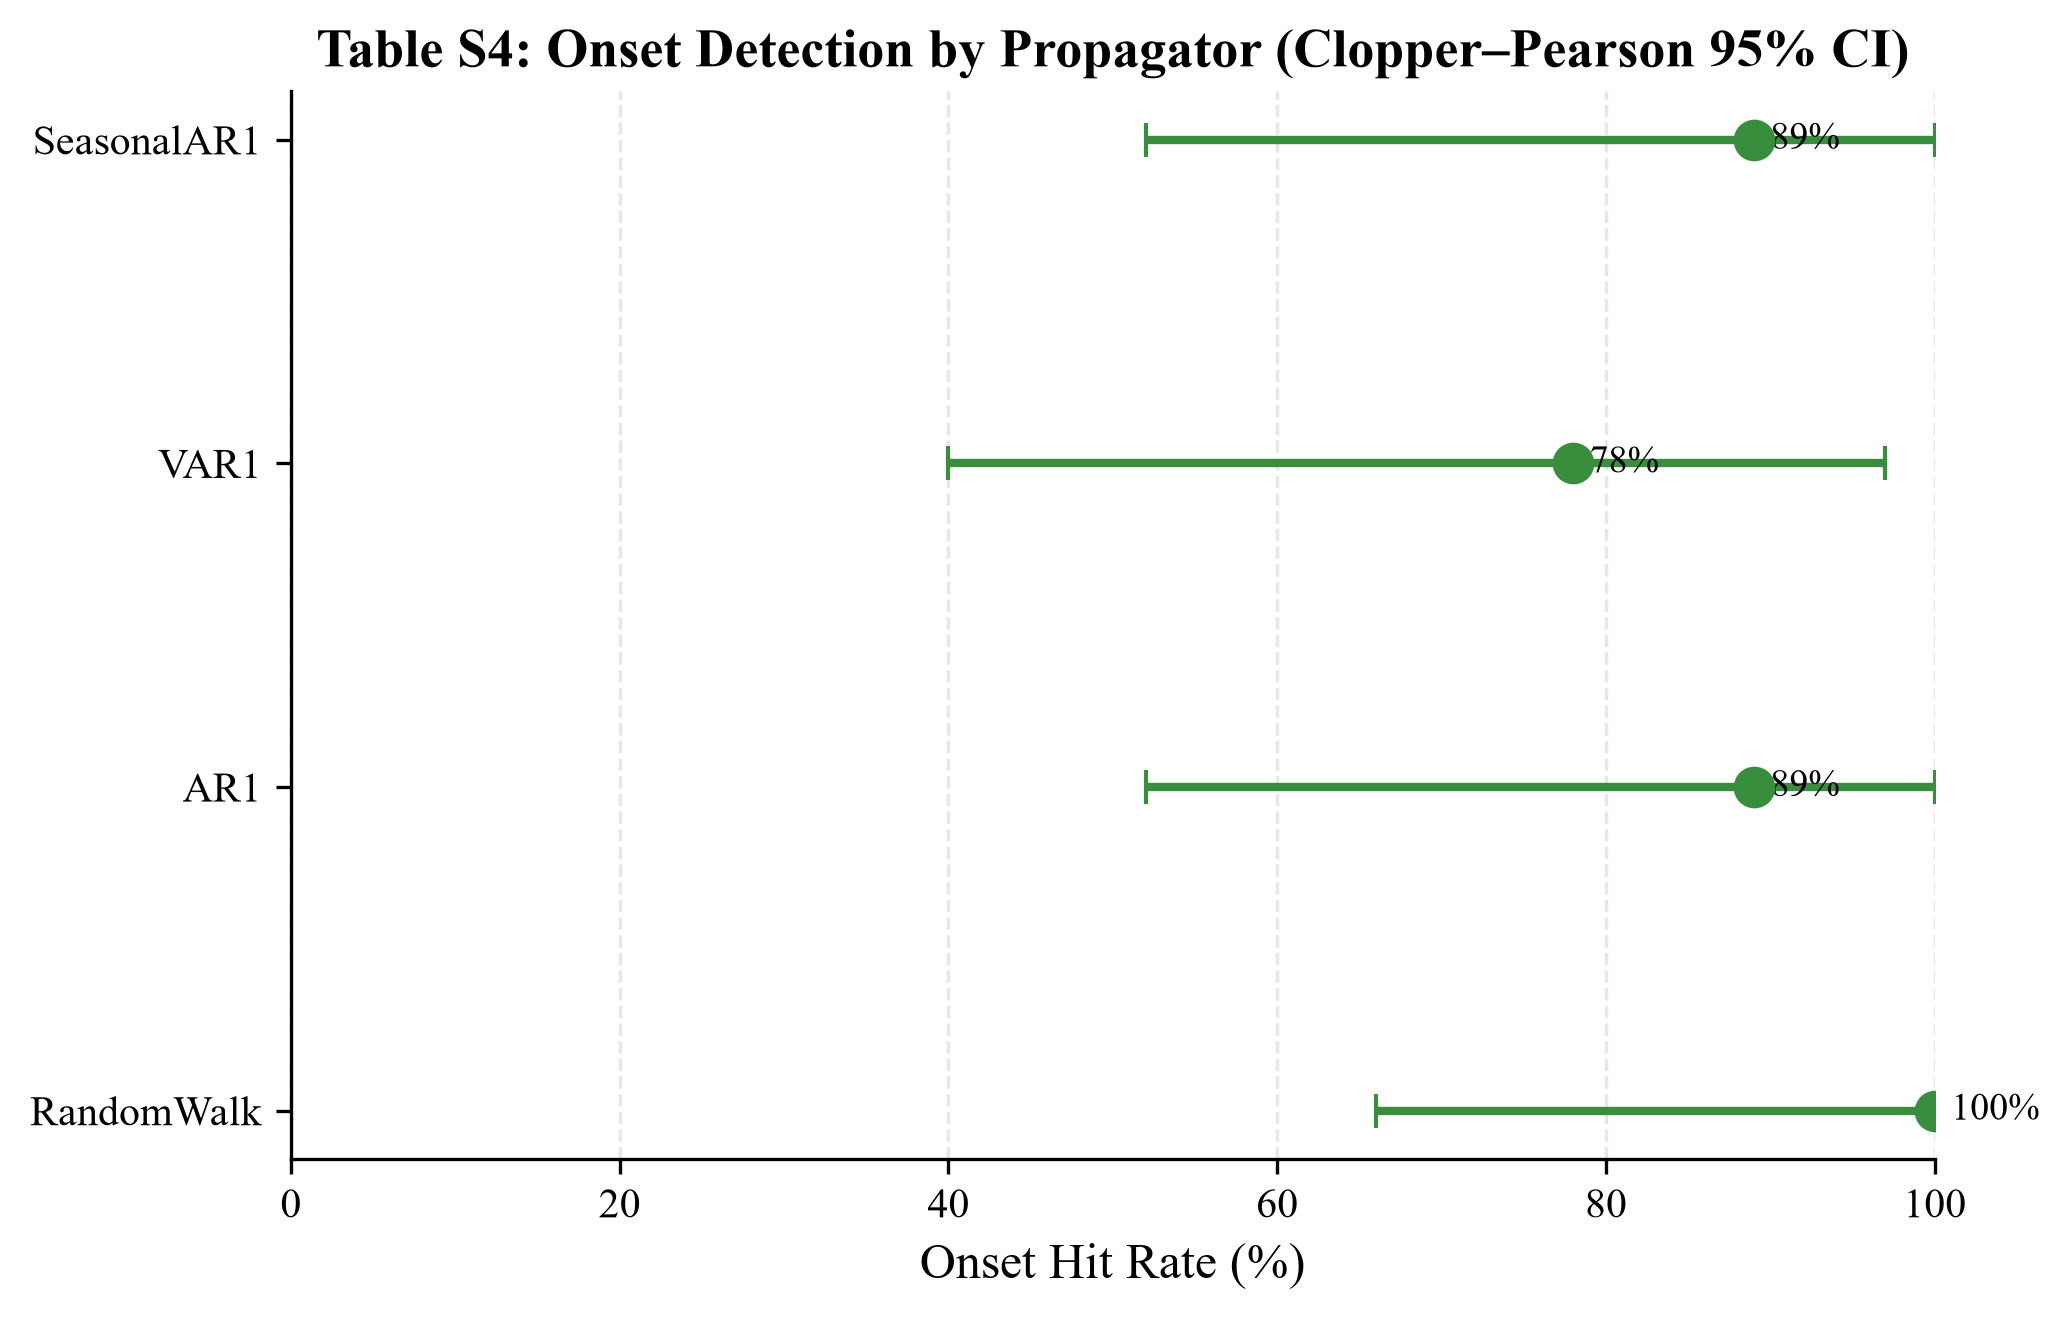

--- Figure: Table S5/S6 (per-bin reliability diagnostic) ---
  Saved: output/Fig_TableS5_brier_decomposition_hybrid.png


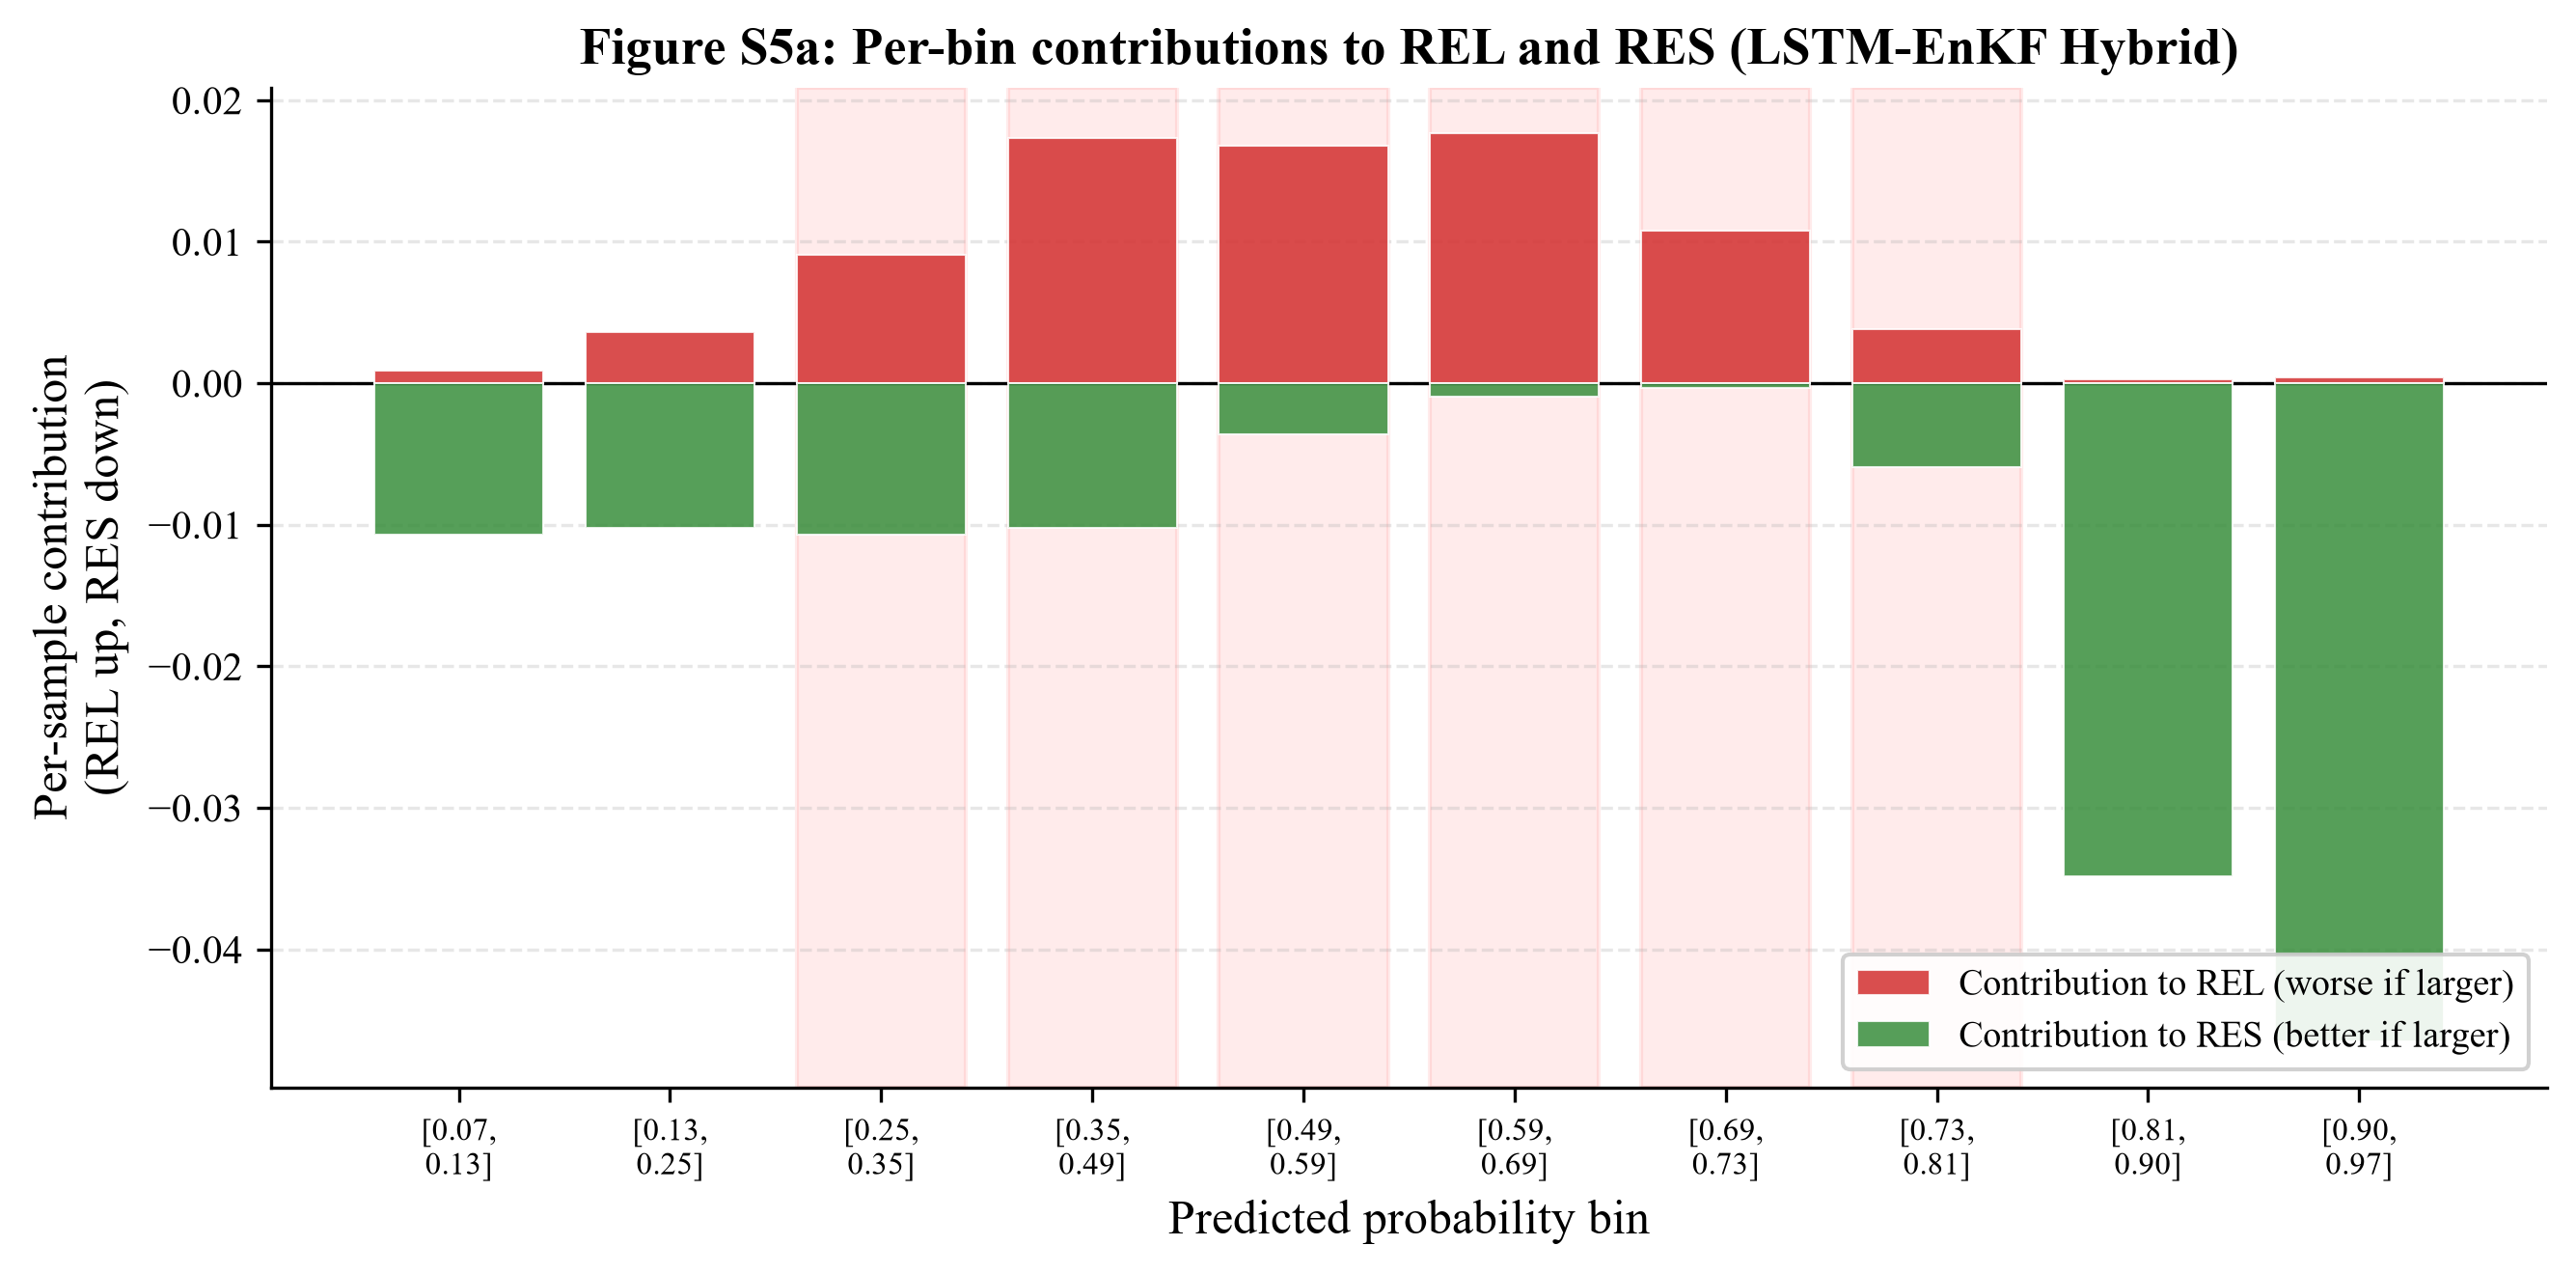

  Saved: output/Fig_TableS5_brier_components.png


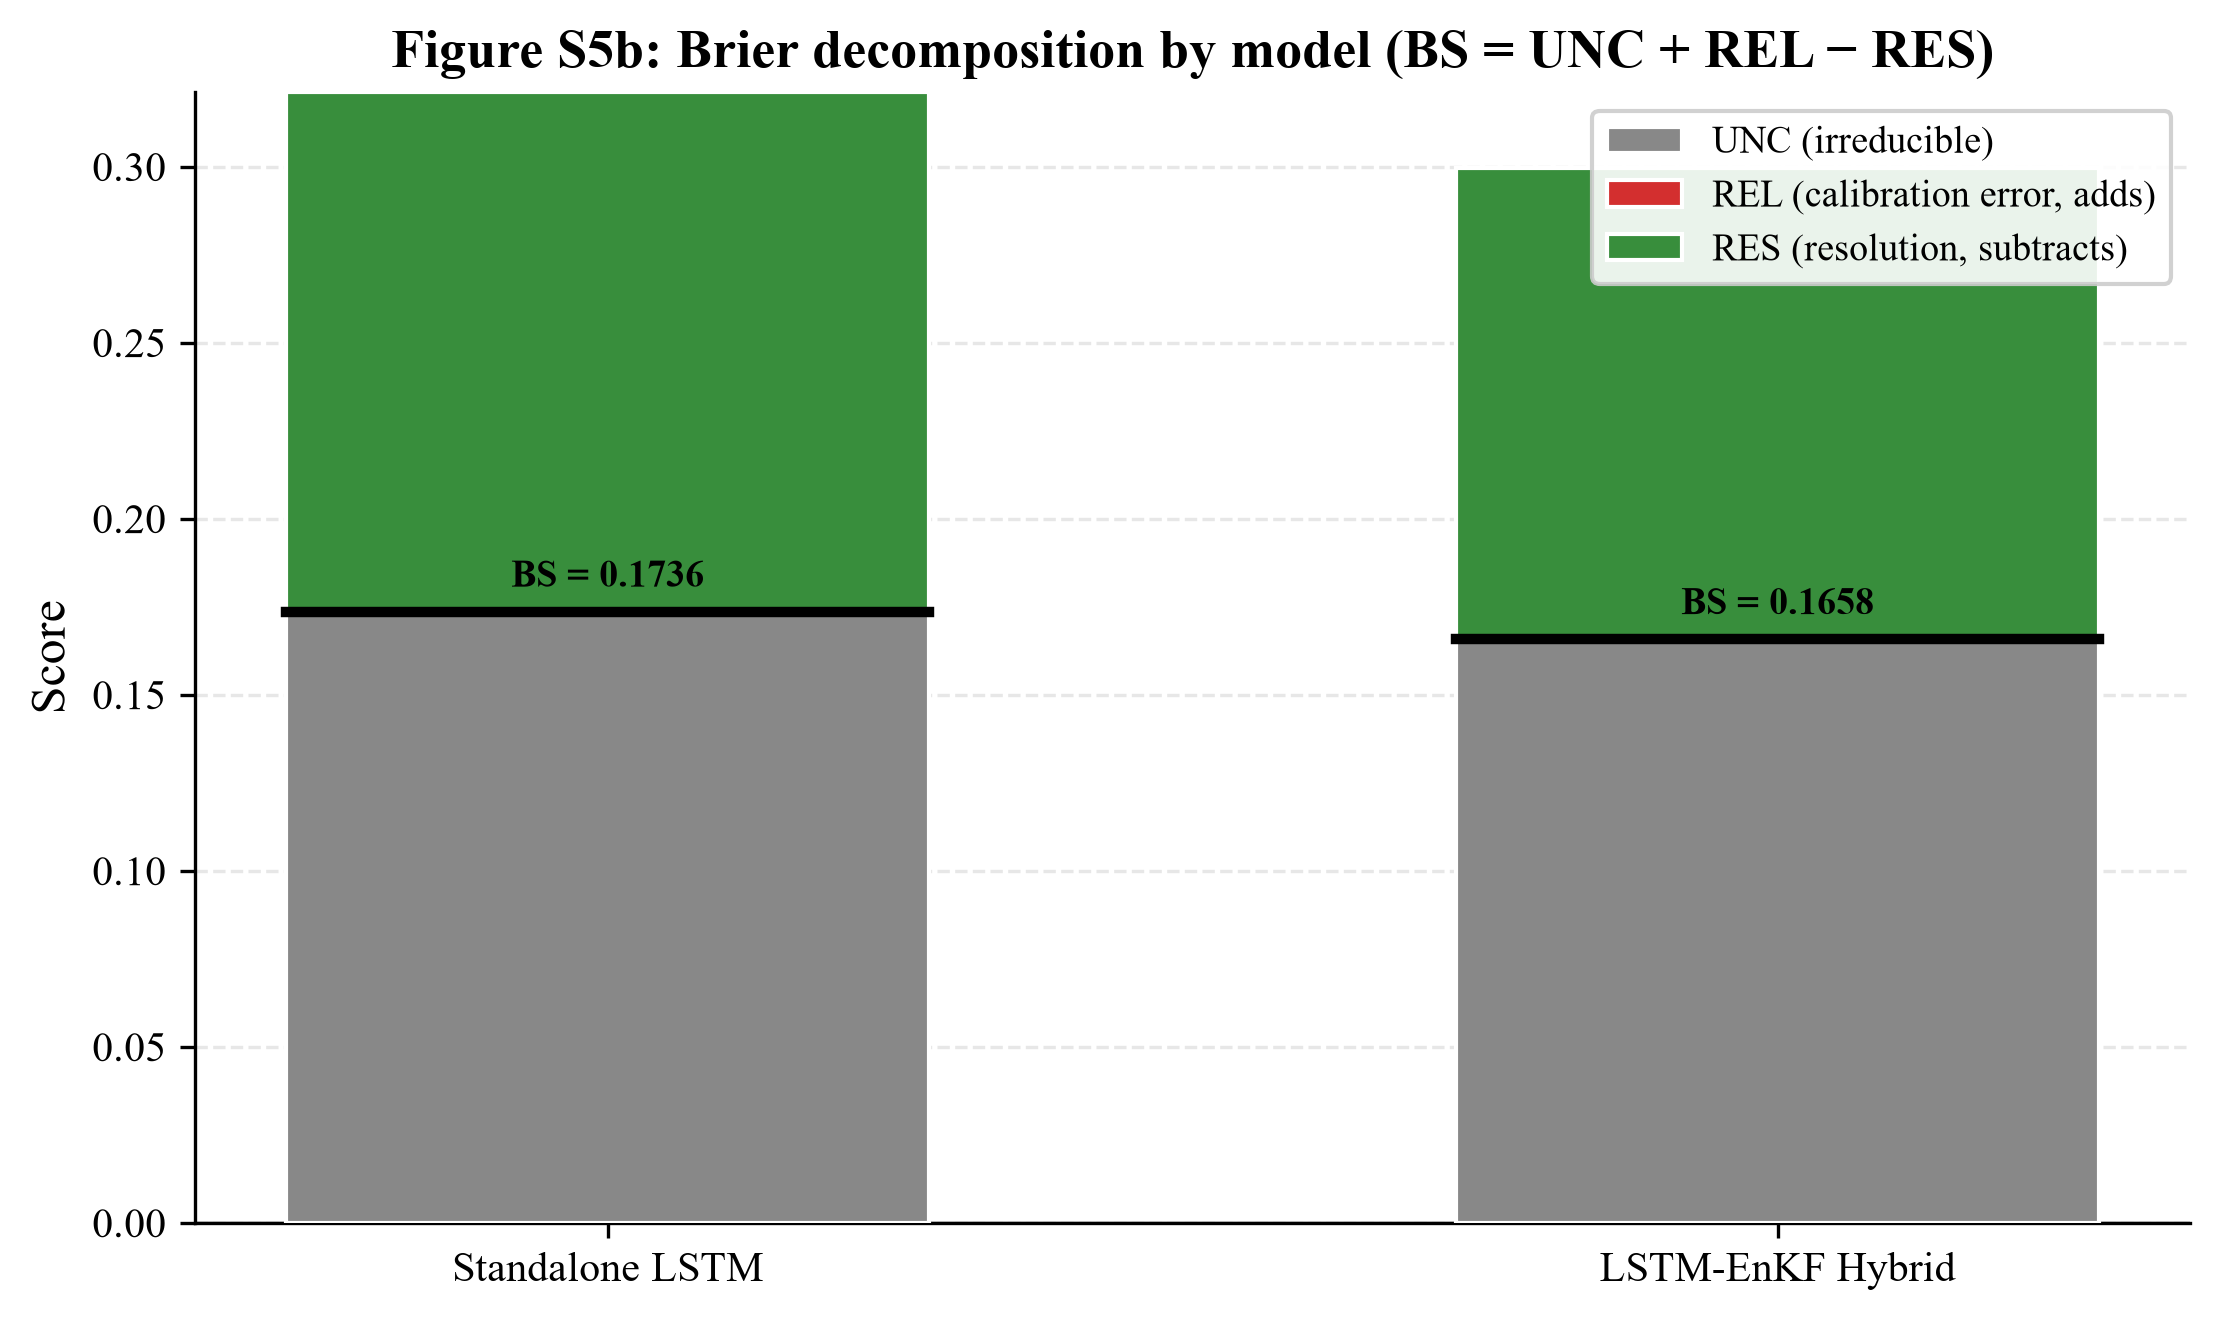


ALL FIGURES GENERATED
  output/Fig_Brier_Onset.png
  output/Fig_Table3_revised.png
  output/Fig_TableS3_forest_plot.png
  output/Fig_TableS3_onset_CI.png
  output/Fig_TableS4_Brier.png
  output/Fig_TableS4_onset.png
  output/Fig_TableS4_propagator.png
  output/Fig_TableS5_brier_components.png
  output/Fig_TableS5_brier_decomposition_hybrid.png

Total: 9 PNG figures (9 PDFs also saved)


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import re
import os

os.makedirs('output', exist_ok=True)


def read_optional_table(path, columns=None):
    """Read a table created by cell 14, treating missing/headerless files as empty."""
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return pd.DataFrame(columns=columns)
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=columns)


# --- Global academic style ---
plt.rcdefaults()
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'Climatology':      '#9E9E9E',
    'Persistence':      '#78909C',
    'Logistic Reg':     '#5C6BC0',
    'Random Forest':    '#26A69A',
    'Standalone LSTM':  '#1976D2',
    'LSTM–EnKF Hybrid': '#D32F2F',
}


METRIC_COLORS = ['#1976D2', '#D32F2F', '#388E3C', '#F57C00']
metric_colors = METRIC_COLORS

# ============================================================================
# HELPER: Parse "90.87% [88.1, 93.2]" into (value, ci_lo, ci_hi)
# ============================================================================
def parse_pct_ci(s):
    """Parse a string like '90.87% [88.1%, 93.2%]' into (val, lo, hi)."""
    if not isinstance(s, str) or s == 'N/A':
        return None, None, None
    nums = re.findall(r'[\d.]+', s)
    if len(nums) >= 3:
        return float(nums[0]), float(nums[1]), float(nums[2])
    elif len(nums) >= 1:
        return float(nums[0]), None, None
    return None, None, None


def parse_brier_ci(s):
    """Parse '0.1236 [0.0901, 0.1584]' into (val, lo, hi)."""
    if not isinstance(s, str) or s == 'N/A':
        return None, None, None
    nums = re.findall(r'[\d.]+', s)
    if len(nums) >= 3:
        return float(nums[0]), float(nums[1]), float(nums[2])
    elif len(nums) >= 1:
        return float(nums[0]), None, None
    return None, None, None


def parse_onset(s):
    """Parse '6/10 (60%) [26, 88]' into (rate, lo, hi)."""
    if not isinstance(s, str) or s == 'N/A':
        return None, None, None
    nums = re.findall(r'[\d.]+', s)
    # Pattern: n_det / n_obs (rate%) [lo, hi]
    if len(nums) >= 4:
        return float(nums[2]), float(nums[3]), float(nums[4]) if len(nums) >= 5 else None
    elif len(nums) >= 3:
        return float(nums[2]), None, None
    return None, None, None


# ============================================================================
# FIGURE 1: REVISED TABLE 3 — MULTI-METRIC BAR CHART WITH CIs
# ============================================================================
print("--- Figure: Revised Table 3 ---")

df3 = pd.read_csv('output/Table3_revised.csv')

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
models = df3['Model'].tolist()
n_models = len(models)
n_metrics = len(metrics_to_plot)

fig, axes = plt.subplots(1, n_metrics, figsize=(3.2 * n_metrics, 5), sharey=True)

for ax_idx, metric in enumerate(metrics_to_plot):
    ax = axes[ax_idx]
    vals, ci_los, ci_his = [], [], []

    for _, row in df3.iterrows():
        v, lo, hi = parse_pct_ci(row[metric])
        vals.append(v if v is not None else 0)
        ci_los.append(lo)
        ci_his.append(hi)

    y_pos = np.arange(n_models)
    bar_colors = [COLORS.get(m, '#888888') for m in models]

    # Error bars (asymmetric)
    xerr_lo = []
    xerr_hi = []
    for i in range(n_models):
        if ci_los[i] is not None and ci_his[i] is not None:
            xerr_lo.append(vals[i] - ci_los[i])
            xerr_hi.append(ci_his[i] - vals[i])
        else:
            xerr_lo.append(0)
            xerr_hi.append(0)

    bars = ax.barh(y_pos, vals, color=bar_colors, edgecolor='white',
                   linewidth=0.5, height=0.65, zorder=3)

    # Add error bars only where CIs exist
    for i in range(n_models):
        if ci_los[i] is not None:
            ax.errorbar(vals[i], y_pos[i], xerr=[[xerr_lo[i]], [xerr_hi[i]]],
                        fmt='none', ecolor='black', capsize=3, capthick=1,
                        linewidth=1, zorder=4)

    # Value labels
    for i, v in enumerate(vals):
        offset = 1.5 if ci_his[i] is None else (ci_his[i] - vals[i]) + 1.5
        ax.text(v + offset, y_pos[i], f'{v:.1f}%',
                va='center', ha='left', fontsize=8, color='#333333')

    ax.set_xlabel(f'{metric} (%)')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.set_yticks(y_pos)

    if ax_idx == 0:
        ax.set_yticklabels(models)
    else:
        ax.set_yticklabels([])

    ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
    ax.grid(axis='x', alpha=0.3, linestyle='--', zorder=0)
    ax.invert_yaxis()

fig.suptitle('Table 3 (Revised): Model Comparison with 95% Bootstrap CIs',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/Fig_Table3_revised.png', dpi=300)
plt.savefig('output/Fig_Table3_revised.pdf')
print("  Saved: output/Fig_Table3_revised.png")
plt.show()


# ============================================================================
# FIGURE 2: BRIER SCORE + ONSET HIT RATE (SIDE BY SIDE)
# ============================================================================
print("--- Figure: Brier Score + Onset Hit Rate ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# --- Panel A: Brier Score ---
brier_vals, brier_lo, brier_hi = [], [], []
for _, row in df3.iterrows():
    v, lo, hi = parse_brier_ci(row['Brier Score'])
    brier_vals.append(v if v is not None else 0)
    brier_lo.append(lo)
    brier_hi.append(hi)

y_pos = np.arange(n_models)
bar_colors = [COLORS.get(m, '#888888') for m in models]

ax1.barh(y_pos, brier_vals, color=bar_colors, edgecolor='white',
         linewidth=0.5, height=0.65, zorder=3)

for i in range(n_models):
    if brier_lo[i] is not None and brier_hi[i] is not None:
        ax1.errorbar(brier_vals[i], y_pos[i],
                     xerr=[[brier_vals[i] - brier_lo[i]], [brier_hi[i] - brier_vals[i]]],
                     fmt='none', ecolor='black', capsize=3, capthick=1, linewidth=1, zorder=4)
    ax1.text(brier_vals[i] + 0.005, y_pos[i], f'{brier_vals[i]:.4f}',
             va='center', ha='left', fontsize=8, color='#333333')

ax1.set_xlabel('Brier Score (lower is better)')
ax1.set_title('(a) Brier Score', fontweight='bold')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--', zorder=0)

# --- Panel B: Onset Hit Rate ---
ohr_vals, ohr_lo, ohr_hi = [], [], []
for _, row in df3.iterrows():
    v, lo, hi = parse_onset(row['Onset Hit Rate'])
    ohr_vals.append(v if v is not None else 0)
    ohr_lo.append(lo)
    ohr_hi.append(hi)

ax2.barh(y_pos, ohr_vals, color=bar_colors, edgecolor='white',
         linewidth=0.5, height=0.65, zorder=3)

for i in range(n_models):
    if ohr_lo[i] is not None and ohr_hi[i] is not None:
        ax2.errorbar(ohr_vals[i], y_pos[i],
                     xerr=[[ohr_vals[i] - ohr_lo[i]], [ohr_hi[i] - ohr_vals[i]]],
                     fmt='none', ecolor='black', capsize=3, capthick=1, linewidth=1, zorder=4)
    ax2.text(ohr_vals[i] + 1.5, y_pos[i], f'{ohr_vals[i]:.0f}%',
             va='center', ha='left', fontsize=8, color='#333333')

ax2.set_xlabel('Onset Hit Rate (%)')
ax2.set_title('(b) Onset Detection', fontweight='bold')
ax2.set_xlim(0, 105)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([])
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3, linestyle='--', zorder=0)

plt.tight_layout()
plt.savefig('output/Fig_Brier_Onset.png', dpi=300)
plt.savefig('output/Fig_Brier_Onset.pdf')
print("  Saved: output/Fig_Brier_Onset.png")
plt.show()


# ============================================================================
# FIGURE 3: TABLE S1 — Q-SCALING SENSITIVITY
# ============================================================================
print("--- Figure: Table S1 (Q-scaling) ---")

df_s1 = read_optional_table('output/TableS1_Q_sensitivity.csv', columns=['Q Scale Factor'])

if len(df_s1) > 0:
    q_labels = df_s1.iloc[:, 0].tolist()
    q_labels_clean = [s.replace(' *', '') for s in q_labels]
    baseline_mask = ['*' in s for s in q_labels]

    s1_metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)']
    available_s1 = [m for m in s1_metrics if m in df_s1.columns]

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(q_labels))
    width = 0.18
    metric_colors = METRIC_COLORS

    for idx, metric in enumerate(available_s1):
        vals = pd.to_numeric(df_s1[metric], errors='coerce').values
        offset = (idx - len(available_s1) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=metric.replace(' (%)', ''),
                       color=metric_colors[idx], edgecolor='white', linewidth=0.5,
                       zorder=3)

    # Mark baseline
    for i, is_base in enumerate(baseline_mask):
        if is_base:
            ax.axvline(x=i, color='gray', linestyle=':', alpha=0.5, zorder=1)
            ax.text(i, ax.get_ylim()[1] - 1, '(baseline)', ha='center',
                    fontsize=8, color='gray', style='italic')

    ax.set_xlabel('Q Scale Factor')
    ax.set_ylabel('Score (%)')
    ax.set_title('Table S1: Classification Sensitivity to Process Noise Scaling',
                 fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(q_labels_clean)
    ax.legend(loc='lower left', frameon=True, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

    # Tighten y-axis around data range
    all_vals = []
    for m in available_s1:
        all_vals.extend(pd.to_numeric(df_s1[m], errors='coerce').dropna().tolist())
    if all_vals:
        ymin = max(0, min(all_vals) - 10)
        ymax = min(100, max(all_vals) + 5)
        ax.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.savefig('output/Fig_TableS1_Q_sensitivity.png', dpi=300)
    plt.savefig('output/Fig_TableS1_Q_sensitivity.pdf')
    print("  Saved: output/Fig_TableS1_Q_sensitivity.png")
    plt.show()

    # --- S1 Panel B: Brier Score line plot ---
    if 'Brier Score' in df_s1.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        brier_vals = pd.to_numeric(df_s1['Brier Score'], errors='coerce').values

        ax.plot(q_labels_clean, brier_vals, 'o-', color='#D32F2F',
                linewidth=2, markersize=8, zorder=3)
        for i, (lbl, v) in enumerate(zip(q_labels_clean, brier_vals)):
            ax.annotate(f'{v:.4f}', (i, v), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=8)
            if baseline_mask[i]:
                ax.plot(i, v, 'o', color='#D32F2F', markersize=12,
                        markerfacecolor='none', markeredgewidth=2, zorder=4)

        ax.set_xlabel('Q Scale Factor')
        ax.set_ylabel('Brier Score (lower is better)')
        ax.set_title('Table S1: Brier Score vs. Process Noise Scaling',
                     fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
        plt.tight_layout()
        plt.savefig('output/Fig_TableS1_Brier.png', dpi=300)
        plt.savefig('output/Fig_TableS1_Brier.pdf')
        print("  Saved: output/Fig_TableS1_Brier.png")
        plt.show()
else:
    print("  TableS1 is empty — skipping. Run Part 19 first.")


# ============================================================================
# FIGURE 4: TABLE S2 — ENSEMBLE SIZE SENSITIVITY
# ============================================================================
print("--- Figure: Table S2 (Ensemble size) ---")

df_s2 = read_optional_table('output/TableS2_N_sensitivity.csv', columns=['Ensemble Size (N)'])

if len(df_s2) > 0:
    n_labels = df_s2.iloc[:, 0].tolist()
    n_labels_clean = [s.replace(' *', '') for s in n_labels]
    baseline_mask_n = ['*' in s for s in n_labels]

    s2_metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)']
    available_s2 = [m for m in s2_metrics if m in df_s2.columns]

    fig, ax = plt.subplots(figsize=(7, 5))
    x = np.arange(len(n_labels))
    width = 0.18

    for idx, metric in enumerate(available_s2):
        vals = pd.to_numeric(df_s2[metric], errors='coerce').values
        offset = (idx - len(available_s2) / 2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=metric.replace(' (%)', ''),
               color=metric_colors[idx], edgecolor='white', linewidth=0.5, zorder=3)

    for i, is_base in enumerate(baseline_mask_n):
        if is_base:
            ax.axvline(x=i, color='gray', linestyle=':', alpha=0.5, zorder=1)
            ax.text(i, ax.get_ylim()[1] - 1, '(baseline)', ha='center',
                    fontsize=8, color='gray', style='italic')

    ax.set_xlabel('Ensemble Size (N)')
    ax.set_ylabel('Score (%)')
    ax.set_title('Table S2: Classification Sensitivity to Ensemble Size',
                 fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(n_labels_clean)
    ax.legend(loc='lower left', frameon=True, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

    all_vals = []
    for m in available_s2:
        all_vals.extend(pd.to_numeric(df_s2[m], errors='coerce').dropna().tolist())
    if all_vals:
        ymin = max(0, min(all_vals) - 10)
        ymax = min(100, max(all_vals) + 5)
        ax.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.savefig('output/Fig_TableS2_N_sensitivity.png', dpi=300)
    plt.savefig('output/Fig_TableS2_N_sensitivity.pdf')
    print("  Saved: output/Fig_TableS2_N_sensitivity.png")
    plt.show()
else:
    print("  TableS2 is empty — skipping. Run Part 19 first.")


# ============================================================================
# FIGURE 5: TABLE S3 — BOOTSTRAP CI COMPARISON (FOREST PLOT)
# ============================================================================
print("--- Figure: Table S3 (Bootstrap CI forest plot) ---")

df_s3 = pd.read_csv('output/TableS3_bootstrap_CIs.csv')

if len(df_s3) > 0:
    # Parse point estimates and CIs for classification metrics (not Brier, not Onset)
    plot_metrics = [m for m in df_s3['Metric'].tolist()
                    if 'Brier' not in m and 'Onset' not in m]

    fig, ax = plt.subplots(figsize=(8, 5))
    y_positions = np.arange(len(plot_metrics))
    offset = 0.15

    for model_idx, (prefix, color, marker) in enumerate([
        ('LSTM', '#1976D2', 'o'),
        ('Hybrid', '#D32F2F', 's')
    ]):
        points, ci_lows, ci_highs = [], [], []

        for metric in plot_metrics:
            row = df_s3[df_s3['Metric'] == metric].iloc[0]
            pt_str = str(row[f'{prefix} Point'])
            ci_str = str(row[f'{prefix} 95% CI'])

            # Parse point
            pt_nums = re.findall(r'[\d.]+', pt_str)
            pt = float(pt_nums[0]) if pt_nums else 0

            # Parse CI
            ci_nums = re.findall(r'[\d.]+', ci_str)
            if len(ci_nums) >= 2:
                lo, hi = float(ci_nums[0]), float(ci_nums[1])
            else:
                lo, hi = pt, pt

            points.append(pt)
            ci_lows.append(lo)
            ci_highs.append(hi)

        y_off = y_positions + (model_idx - 0.5) * offset * 2

        # Plot CIs as horizontal lines
        for i in range(len(plot_metrics)):
            ax.plot([ci_lows[i], ci_highs[i]], [y_off[i], y_off[i]],
                    color=color, linewidth=2, zorder=3)
            # Caps
            ax.plot([ci_lows[i], ci_lows[i]],
                    [y_off[i] - 0.06, y_off[i] + 0.06],
                    color=color, linewidth=1.5, zorder=3)
            ax.plot([ci_highs[i], ci_highs[i]],
                    [y_off[i] - 0.06, y_off[i] + 0.06],
                    color=color, linewidth=1.5, zorder=3)

        # Point estimates
        label = 'Standalone LSTM' if prefix == 'LSTM' else 'LSTM–EnKF Hybrid'
        ax.scatter(points, y_off, color=color, marker=marker, s=60,
                   zorder=4, label=label, edgecolors='white', linewidth=0.5)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_metrics)
    ax.set_xlabel('Score (%)')
    ax.set_title('Table S3: Bootstrap 95% Confidence Intervals by Model',
                 fontweight='bold')
    ax.legend(loc='lower right', frameon=True, framealpha=0.9)
    ax.grid(axis='x', alpha=0.3, linestyle='--', zorder=0)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig('output/Fig_TableS3_forest_plot.png', dpi=300)
    plt.savefig('output/Fig_TableS3_forest_plot.pdf')
    print("  Saved: output/Fig_TableS3_forest_plot.png")
    plt.show()

    # --- S3 Panel B: Onset Hit Rate CI comparison ---
    onset_rows = df_s3[df_s3['Metric'].str.contains('Onset')]
    if len(onset_rows) > 0:
        fig, ax = plt.subplots(figsize=(6, 3))
        row = onset_rows.iloc[0]

        for model_idx, (prefix, color, label) in enumerate([
            ('LSTM', '#1976D2', 'Standalone LSTM'),
            ('Hybrid', '#D32F2F', 'LSTM–EnKF Hybrid')
        ]):
            pt_nums = re.findall(r'[\d.]+', str(row[f'{prefix} Point']))
            ci_nums = re.findall(r'[\d.]+', str(row[f'{prefix} 95% CI']))
            pt = float(pt_nums[0]) if pt_nums else 0
            lo = float(ci_nums[0]) if len(ci_nums) >= 1 else pt
            hi = float(ci_nums[1]) if len(ci_nums) >= 2 else pt

            y = model_idx
            ax.plot([lo, hi], [y, y], color=color, linewidth=3, zorder=3)
            ax.plot([lo, lo], [y - 0.1, y + 0.1], color=color, linewidth=2, zorder=3)
            ax.plot([hi, hi], [y - 0.1, y + 0.1], color=color, linewidth=2, zorder=3)
            ax.scatter([pt], [y], color=color, s=100, zorder=4,
                       edgecolors='white', linewidth=1)
            ax.text(hi + 2, y, f'{pt:.0f}%', va='center', fontsize=10,
                    color=color, fontweight='bold')

        # Overlap shading
        all_ci = re.findall(r'[\d.]+', str(onset_rows.iloc[0]['LSTM 95% CI']) +
                            str(onset_rows.iloc[0]['Hybrid 95% CI']))
        if len(all_ci) >= 4:
            lo_l, hi_l = float(all_ci[0]), float(all_ci[1])
            lo_h, hi_h = float(all_ci[2]), float(all_ci[3])
            overlap_lo = max(lo_l, lo_h)
            overlap_hi = min(hi_l, hi_h)
            if overlap_lo < overlap_hi:
                ax.axvspan(overlap_lo, overlap_hi, alpha=0.15, color='purple',
                           zorder=1, label='CI Overlap')

        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Standalone\nLSTM', 'LSTM–EnKF\nHybrid'])
        ax.set_xlabel('Onset Hit Rate (%)')
        ax.set_title('Onset Detection: Clopper-Pearson 95% CIs',
                     fontweight='bold')
        ax.set_xlim(0, 100)
        ax.grid(axis='x', alpha=0.3, linestyle='--', zorder=0)
        if overlap_lo < overlap_hi:
            ax.legend(loc='upper right', fontsize=8)

        plt.tight_layout()
        plt.savefig('output/Fig_TableS3_onset_CI.png', dpi=300)
        plt.savefig('output/Fig_TableS3_onset_CI.pdf')
        print("  Saved: output/Fig_TableS3_onset_CI.png")
        plt.show()
else:
    print("  TableS3 is empty — skipping. Run Part 18 first.")




# ============================================================================
# FIGURE 6: TABLE S4 — PROPAGATOR SENSITIVITY (Experiment C)
# ============================================================================
print("--- Figure: Table S4 (propagator sensitivity) ---")

s4_path = 'output/TableS4_propagator_sensitivity.csv'
df_s4 = read_optional_table(s4_path, columns=['Propagator'])

if len(df_s4) > 0:
    p_labels = df_s4['Propagator'].tolist()
    p_labels_clean = [s.replace(' *', '') for s in p_labels]
    baseline_mask_p = ['*' in s for s in p_labels]

    s4_metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)']
    available_s4 = [m for m in s4_metrics if m in df_s4.columns]

    # --- Panel A: classification metrics ---
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(p_labels))
    width = 0.18

    for idx, metric in enumerate(available_s4):
        vals = pd.to_numeric(df_s4[metric], errors='coerce').values
        offset = (idx - len(available_s4) / 2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=metric.replace(' (%)', ''),
               color=metric_colors[idx], edgecolor='white', linewidth=0.5, zorder=3)

    for i, is_base in enumerate(baseline_mask_p):
        if is_base:
            ax.axvline(x=i, color='gray', linestyle=':', alpha=0.5, zorder=1)
            ax.text(i, ax.get_ylim()[1] - 1, '(baseline)', ha='center',
                    fontsize=8, color='gray', style='italic')

    ax.set_xlabel('Driver propagation model')
    ax.set_ylabel('Score (%)')
    ax.set_title('Table S4: Classification Sensitivity to Driver Propagator',
                 fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(p_labels_clean)
    ax.legend(loc='lower left', frameon=True, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

    all_vals = []
    for m in available_s4:
        all_vals.extend(pd.to_numeric(df_s4[m], errors='coerce').dropna().tolist())
    if all_vals:
        ymin = max(0, min(all_vals) - 10)
        ymax = min(100, max(all_vals) + 5)
        ax.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.savefig('output/Fig_TableS4_propagator.png', dpi=300)
    plt.savefig('output/Fig_TableS4_propagator.pdf')
    print("  Saved: output/Fig_TableS4_propagator.png")
    plt.show()

    # --- Panel B: Brier Score line ---
    if 'Brier Score' in df_s4.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        brier_vals = pd.to_numeric(df_s4['Brier Score'], errors='coerce').values

        ax.plot(p_labels_clean, brier_vals, 'o-', color='#D32F2F',
                linewidth=2, markersize=8, zorder=3)
        for i, (lbl, v) in enumerate(zip(p_labels_clean, brier_vals)):
            ax.annotate(f'{v:.4f}', (i, v), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=8)
            if baseline_mask_p[i]:
                ax.plot(i, v, 'o', color='#D32F2F', markersize=12,
                        markerfacecolor='none', markeredgewidth=2, zorder=4)

        ax.set_xlabel('Driver propagation model')
        ax.set_ylabel('Brier Score (lower is better)')
        ax.set_title('Table S4: Brier Score by Propagator',
                     fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
        plt.tight_layout()
        plt.savefig('output/Fig_TableS4_Brier.png', dpi=300)
        plt.savefig('output/Fig_TableS4_Brier.pdf')
        print("  Saved: output/Fig_TableS4_Brier.png")
        plt.show()

    # --- Panel C: Onset Hit Rate with Clopper-Pearson CIs ---
    if 'Onset Hit Rate' in df_s4.columns:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        ohr_points, ohr_lo, ohr_hi = [], [], []
        for _, row in df_s4.iterrows():
            ohr_str = str(row['Onset Hit Rate'])
            nums = re.findall(r'[\d.]+', ohr_str)
            # Expected format: "n/10 (XX%) [LO, HI]"
            if len(nums) >= 5:
                pct = float(nums[2])
                lo, hi = float(nums[3]), float(nums[4])
            elif len(nums) >= 3:
                pct = float(nums[2]); lo, hi = pct, pct
            else:
                pct, lo, hi = float('nan'), float('nan'), float('nan')
            ohr_points.append(pct); ohr_lo.append(lo); ohr_hi.append(hi)

        y_pos = np.arange(len(p_labels))
        ax.errorbar(ohr_points, y_pos,
                    xerr=[np.subtract(ohr_points, ohr_lo),
                          np.subtract(ohr_hi, ohr_points)],
                    fmt='o', color='#388E3C', markersize=9, linewidth=2,
                    capsize=4, zorder=3)
        for i, (pt, lbl) in enumerate(zip(ohr_points, p_labels_clean)):
            ax.text(pt + 1, i, f'{pt:.0f}%', va='center', fontsize=9)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(p_labels_clean)
        ax.set_xlabel('Onset Hit Rate (%)')
        ax.set_xlim(0, 100)
        ax.set_title('Table S4: Onset Detection by Propagator (Clopper–Pearson 95% CI)',
                     fontweight='bold')
        ax.grid(axis='x', alpha=0.3, linestyle='--', zorder=0)
        plt.tight_layout()
        plt.savefig('output/Fig_TableS4_onset.png', dpi=300)
        plt.savefig('output/Fig_TableS4_onset.pdf')
        print("  Saved: output/Fig_TableS4_onset.png")
        plt.show()
else:
    print("  TableS4 is empty — skipping. Run notebook 05 Part 20 first.")




# ============================================================================
# FIGURE 7: TABLE S5/S6 — PER-BIN RELIABILITY DIAGNOSTIC
# ============================================================================
print("--- Figure: Table S5/S6 (per-bin reliability diagnostic) ---")

bin_files = {
    'Standalone LSTM':   'output/_brier_bins_lstm_raw.csv',
    'LSTM-EnKF Hybrid':  'output/_brier_bins_hybrid_raw.csv',
}
bin_frames = {k: pd.read_csv(v) for k, v in bin_files.items() if os.path.exists(v)}

if bin_frames:
    # --- Panel A: per-bin REL and RES contributions (stacked bar, hybrid) ---
    if 'LSTM-EnKF Hybrid' in bin_frames:
        bt_h = bin_frames['LSTM-EnKF Hybrid'].sort_values('bin').reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(9, 4.5))
        x = np.arange(len(bt_h))
        ax.bar(x, bt_h['rel_contrib'].values, color='#D32F2F', alpha=0.85,
               label='Contribution to REL (worse if larger)', edgecolor='white',
               linewidth=0.5, zorder=3)
        ax.bar(x, -bt_h['res_contrib'].values, color='#388E3C', alpha=0.85,
               label='Contribution to RES (better if larger)', edgecolor='white',
               linewidth=0.5, zorder=3)
        ax.axhline(0, color='k', lw=0.8)

        # Mid-probability bins (most reliability error lives here)
        for i, row in bt_h.iterrows():
            if 0.21 <= row['mean_pred'] <= 0.77:
                ax.axvspan(i - 0.4, i + 0.4, alpha=0.08, color='red', zorder=0)

        ax.set_xticks(x)
        ax.set_xticklabels([f"[{r.edge_lo:.2f},\n{r.edge_hi:.2f}]"
                            for _, r in bt_h.iterrows()], fontsize=8)
        ax.set_xlabel('Predicted probability bin')
        ax.set_ylabel('Per-sample contribution\n(REL up, RES down)')
        ax.set_title('Figure S5a: Per-bin contributions to REL and RES (LSTM-EnKF Hybrid)',
                     fontweight='bold')
        ax.legend(loc='lower right', frameon=True, framealpha=0.9, fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
        plt.tight_layout()
        plt.savefig('output/Fig_TableS5_brier_decomposition_hybrid.png', dpi=300)
        plt.savefig('output/Fig_TableS5_brier_decomposition_hybrid.pdf')
        print("  Saved: output/Fig_TableS5_brier_decomposition_hybrid.png")
        plt.show()

    # --- Panel B: side-by-side REL/RES/UNC stacked bars across models ---
    if os.path.exists('output/TableS5_brier_decomposition.csv'):
        df_s5 = pd.read_csv('output/TableS5_brier_decomposition.csv')
        if len(df_s5) >= 1:
            fig, ax = plt.subplots(figsize=(7.5, 4.5))
            models = df_s5['Model'].tolist()
            x = np.arange(len(models))
            rel = pd.to_numeric(df_s5['Reliability (REL)'], errors='coerce').values
            res = pd.to_numeric(df_s5['Resolution (RES)'], errors='coerce').values
            unc = pd.to_numeric(df_s5['Uncertainty (UNC)'], errors='coerce').values
            bs  = pd.to_numeric(df_s5['Brier (raw)'],       errors='coerce').values

            # BS = REL - RES + UNC, plotted as: UNC bar (height UNC) with REL stacked
            # on top and RES carved out from below
            width = 0.55
            ax.bar(x, unc, width, color='#888888', label='UNC (irreducible)',
                   zorder=3, edgecolor='white')
            ax.bar(x, rel, width, bottom=unc, color='#D32F2F',
                   label='REL (calibration error, adds)', zorder=3, edgecolor='white')
            ax.bar(x, -res, width, bottom=unc + rel, color='#388E3C',
                   label='RES (resolution, subtracts)', zorder=3, edgecolor='white')

            # Mark final Brier score
            for i, b in enumerate(bs):
                ax.plot([i - width/2, i + width/2], [b, b], 'k-', lw=2.5, zorder=5)
                ax.annotate(f'BS = {b:.4f}', xy=(i, b), xytext=(0, 6),
                            textcoords='offset points', ha='center',
                            fontsize=9, fontweight='bold')

            ax.set_xticks(x)
            ax.set_xticklabels(models)
            ax.set_ylabel('Score')
            ax.set_title('Figure S5b: Brier decomposition by model (BS = UNC + REL − RES)',
                         fontweight='bold')
            ax.legend(loc='upper right', frameon=True, framealpha=0.9, fontsize=9)
            ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
            ax.axhline(0, color='k', lw=0.8)
            plt.tight_layout()
            plt.savefig('output/Fig_TableS5_brier_components.png', dpi=300)
            plt.savefig('output/Fig_TableS5_brier_components.pdf')
            print("  Saved: output/Fig_TableS5_brier_components.png")
            plt.show()
else:
    print("  Per-bin CSVs not found — run the Brier decomposition cell first.")


# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 60)
print("ALL FIGURES GENERATED")
print("=" * 60)
generated = [f for f in os.listdir('output') if f.startswith('Fig_') and f.endswith('.png')]
for f in sorted(generated):
    print(f"  output/{f}")
print(f"\nTotal: {len(generated)} PNG figures ({len(generated)} PDFs also saved)")

## Pipeline complete

In [10]:
print("All eight pipeline notebooks have run end-to-end.")
print(f"Final comparison table: {os.path.join(OUTPUT_DIR, 'model_comparison.csv')}")
print(f"Supplementary outputs:  output/")


All eight pipeline notebooks have run end-to-end.
Final comparison table: output_refactored/model_comparison.csv
Supplementary outputs:  output/
